## Mounting Drive and Extracting the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

extract_dir = '/content/'
os.makedirs(extract_dir, exist_ok=True)

!tar -xf /content/drive/MyDrive/DNN_Dataset/yolov10n.tar -C {extract_dir}

print(f"Extraction complete! Files are located in {extract_dir}")

Extraction complete! Files are located in /content/


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.4 MB/s eta 0:00:00


## Metrics Visualization

Found 17 visualizations. Displaying them below:

--------------------------------------------------------------------------------
Showing: BoxF1_curve.png


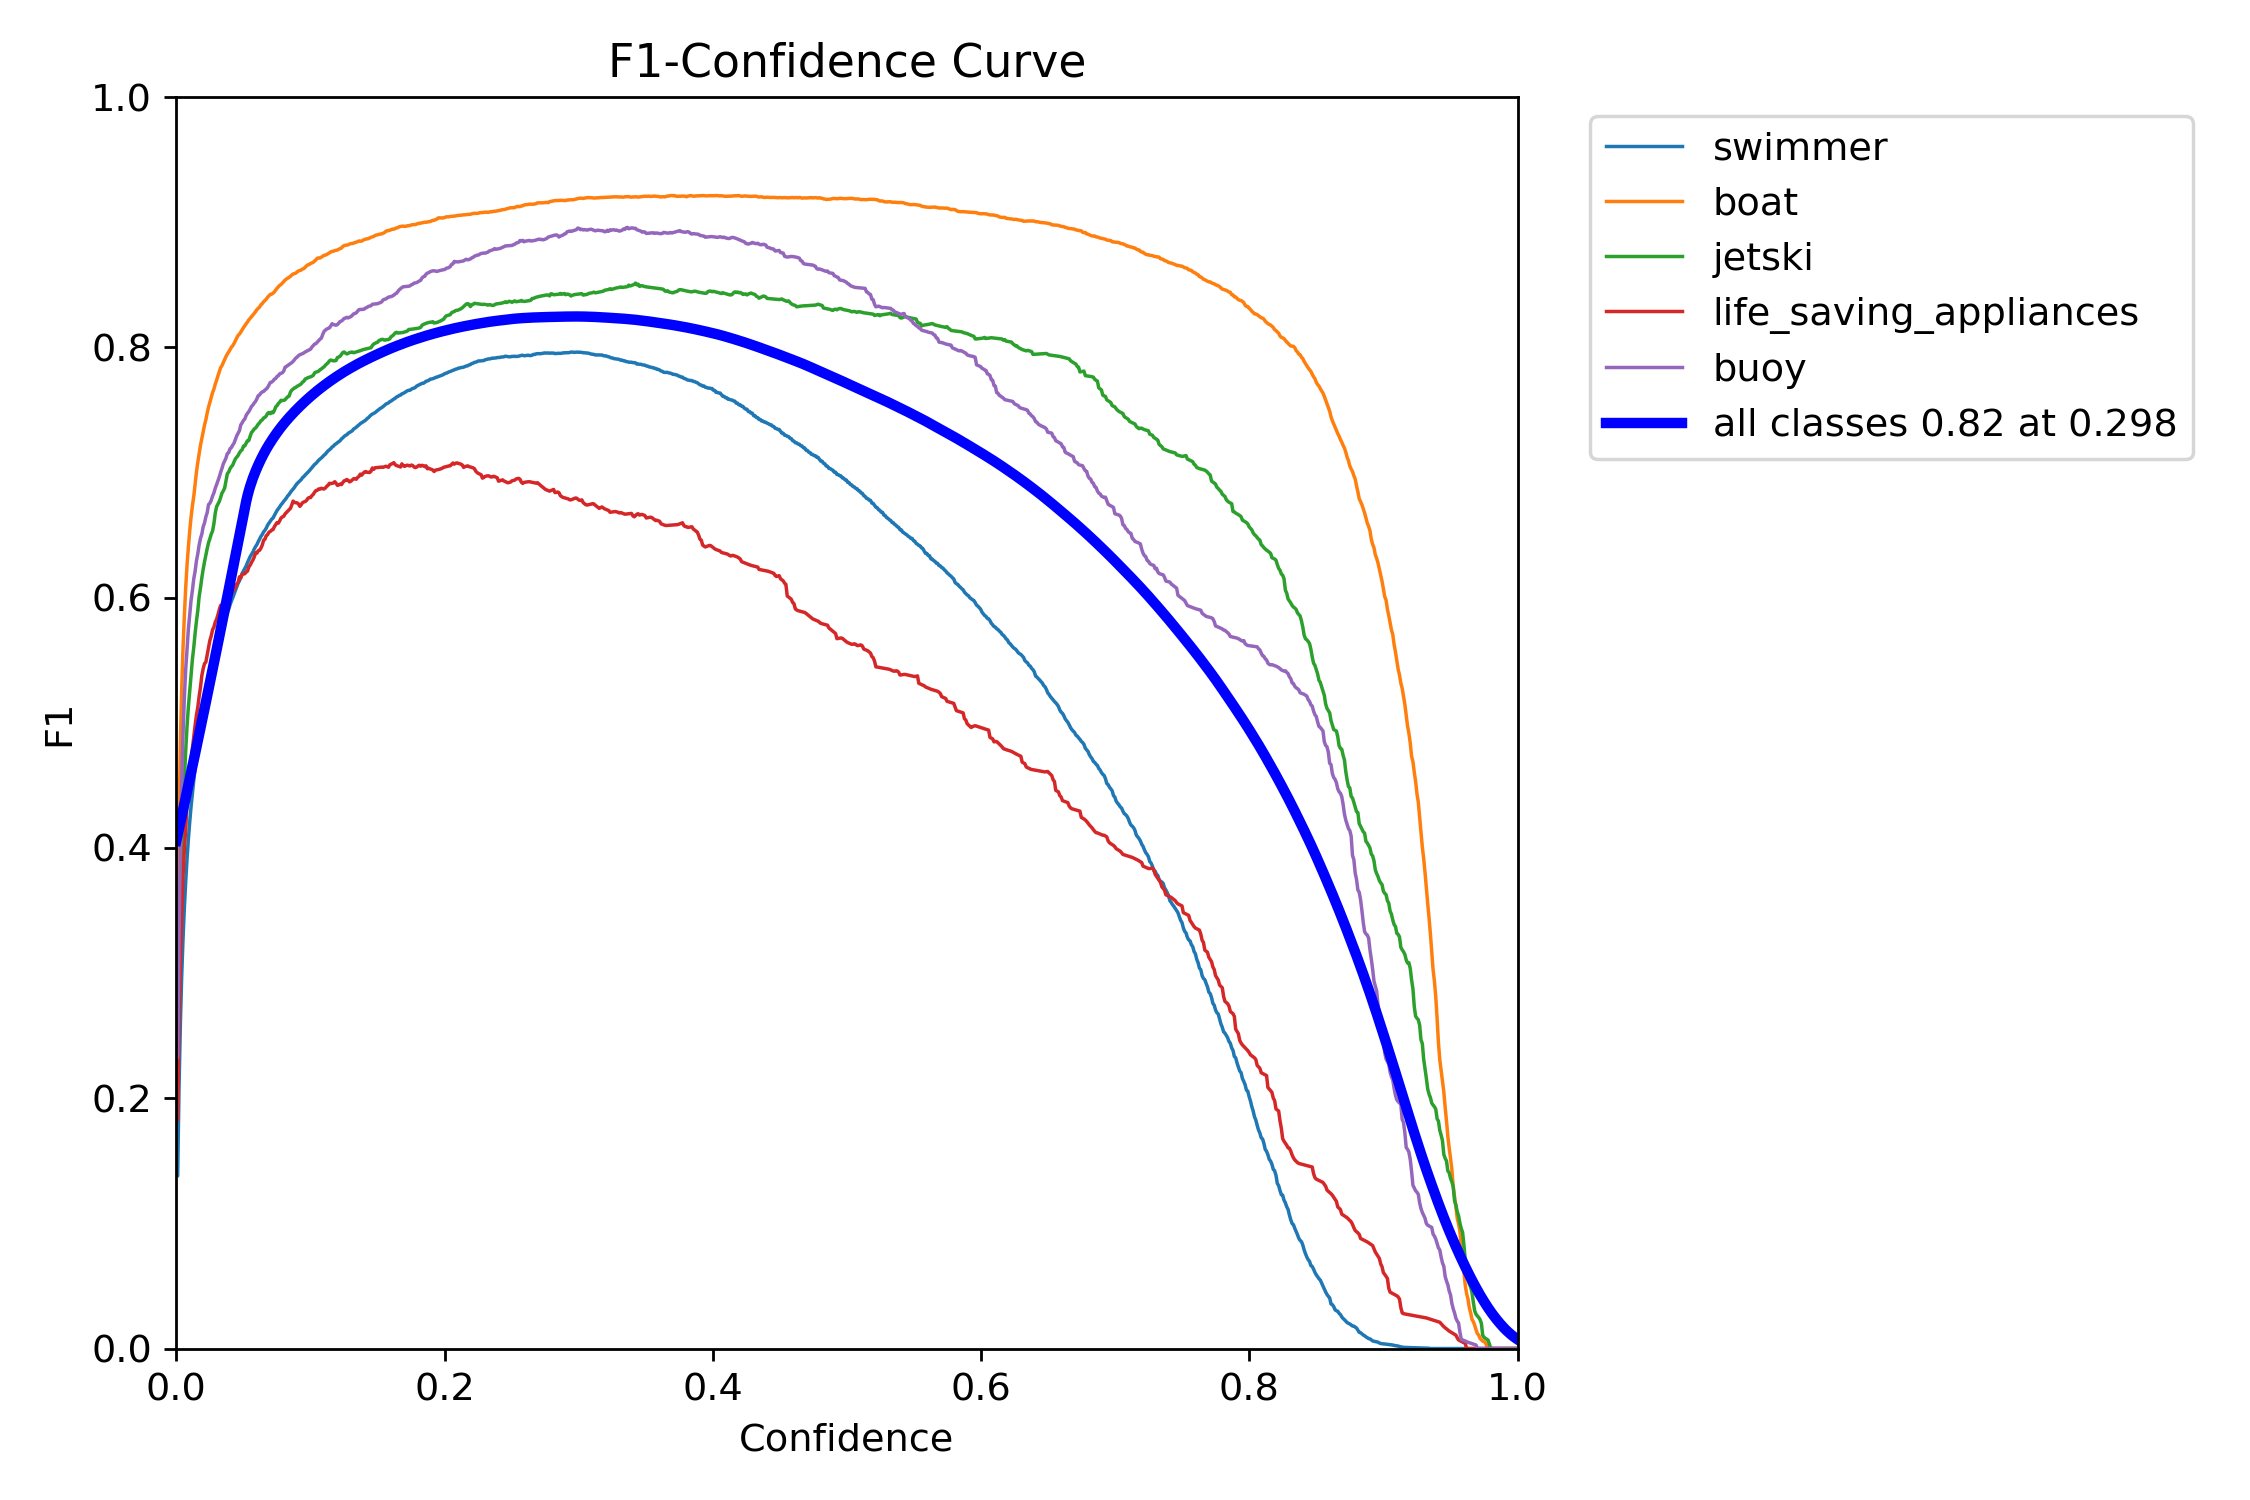

--------------------------------------------------------------------------------
Showing: BoxPR_curve.png


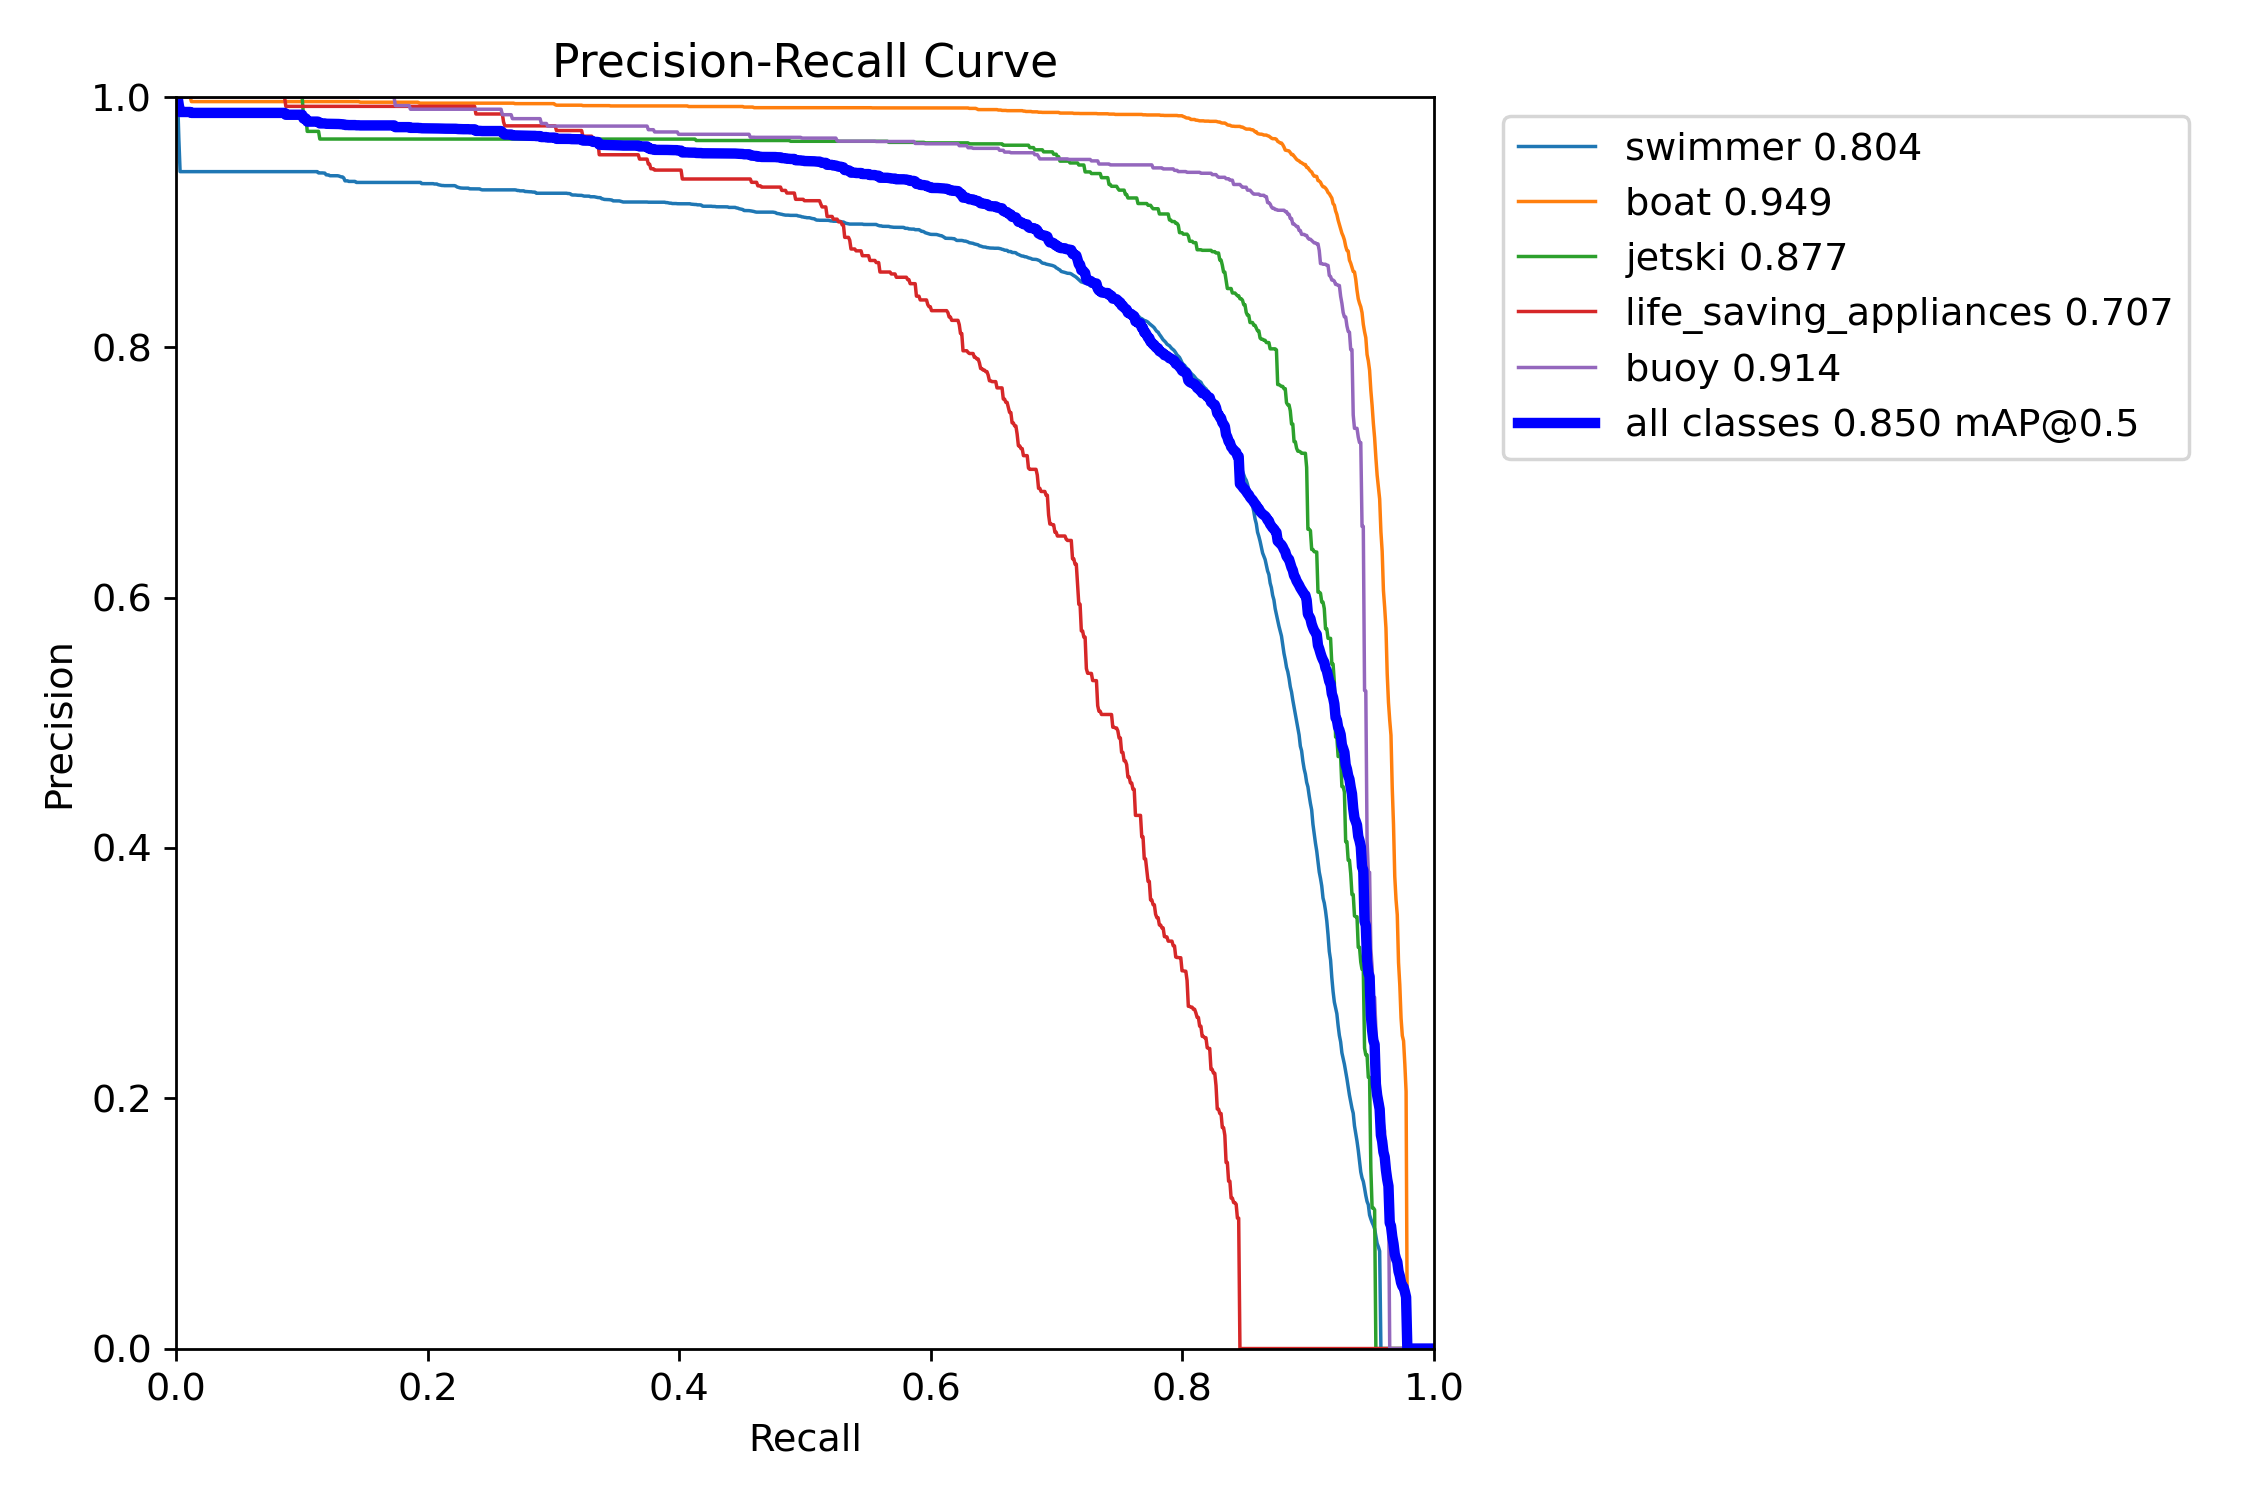

--------------------------------------------------------------------------------
Showing: BoxP_curve.png


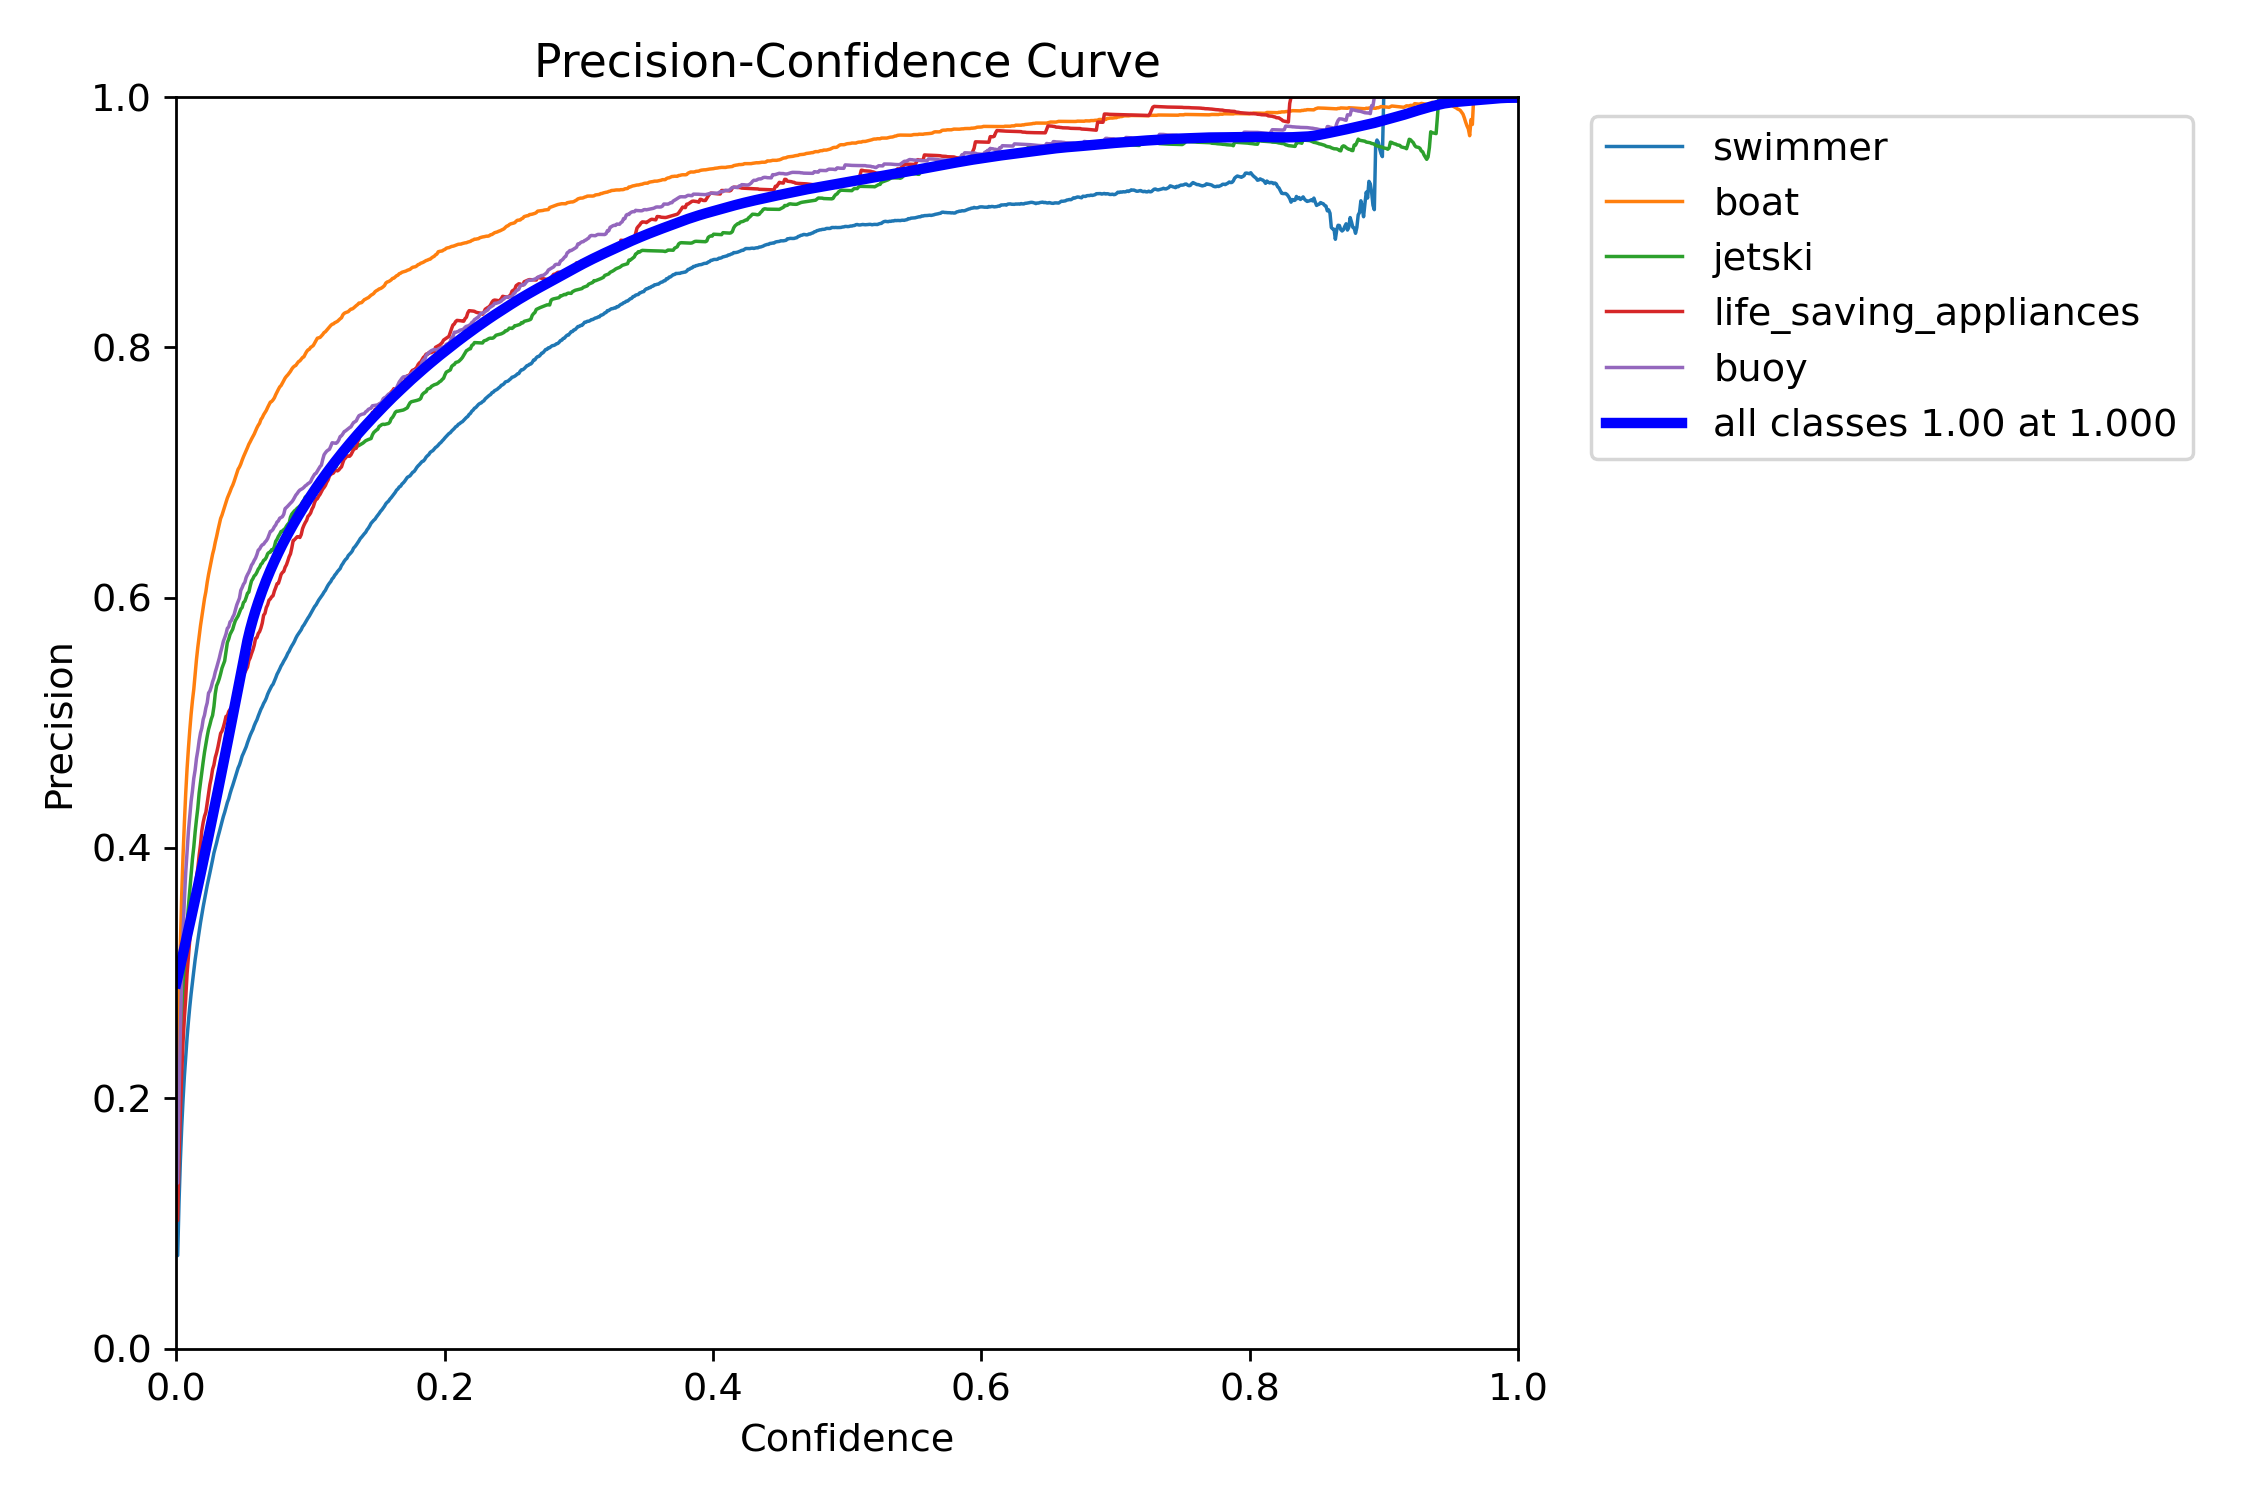

--------------------------------------------------------------------------------
Showing: BoxR_curve.png


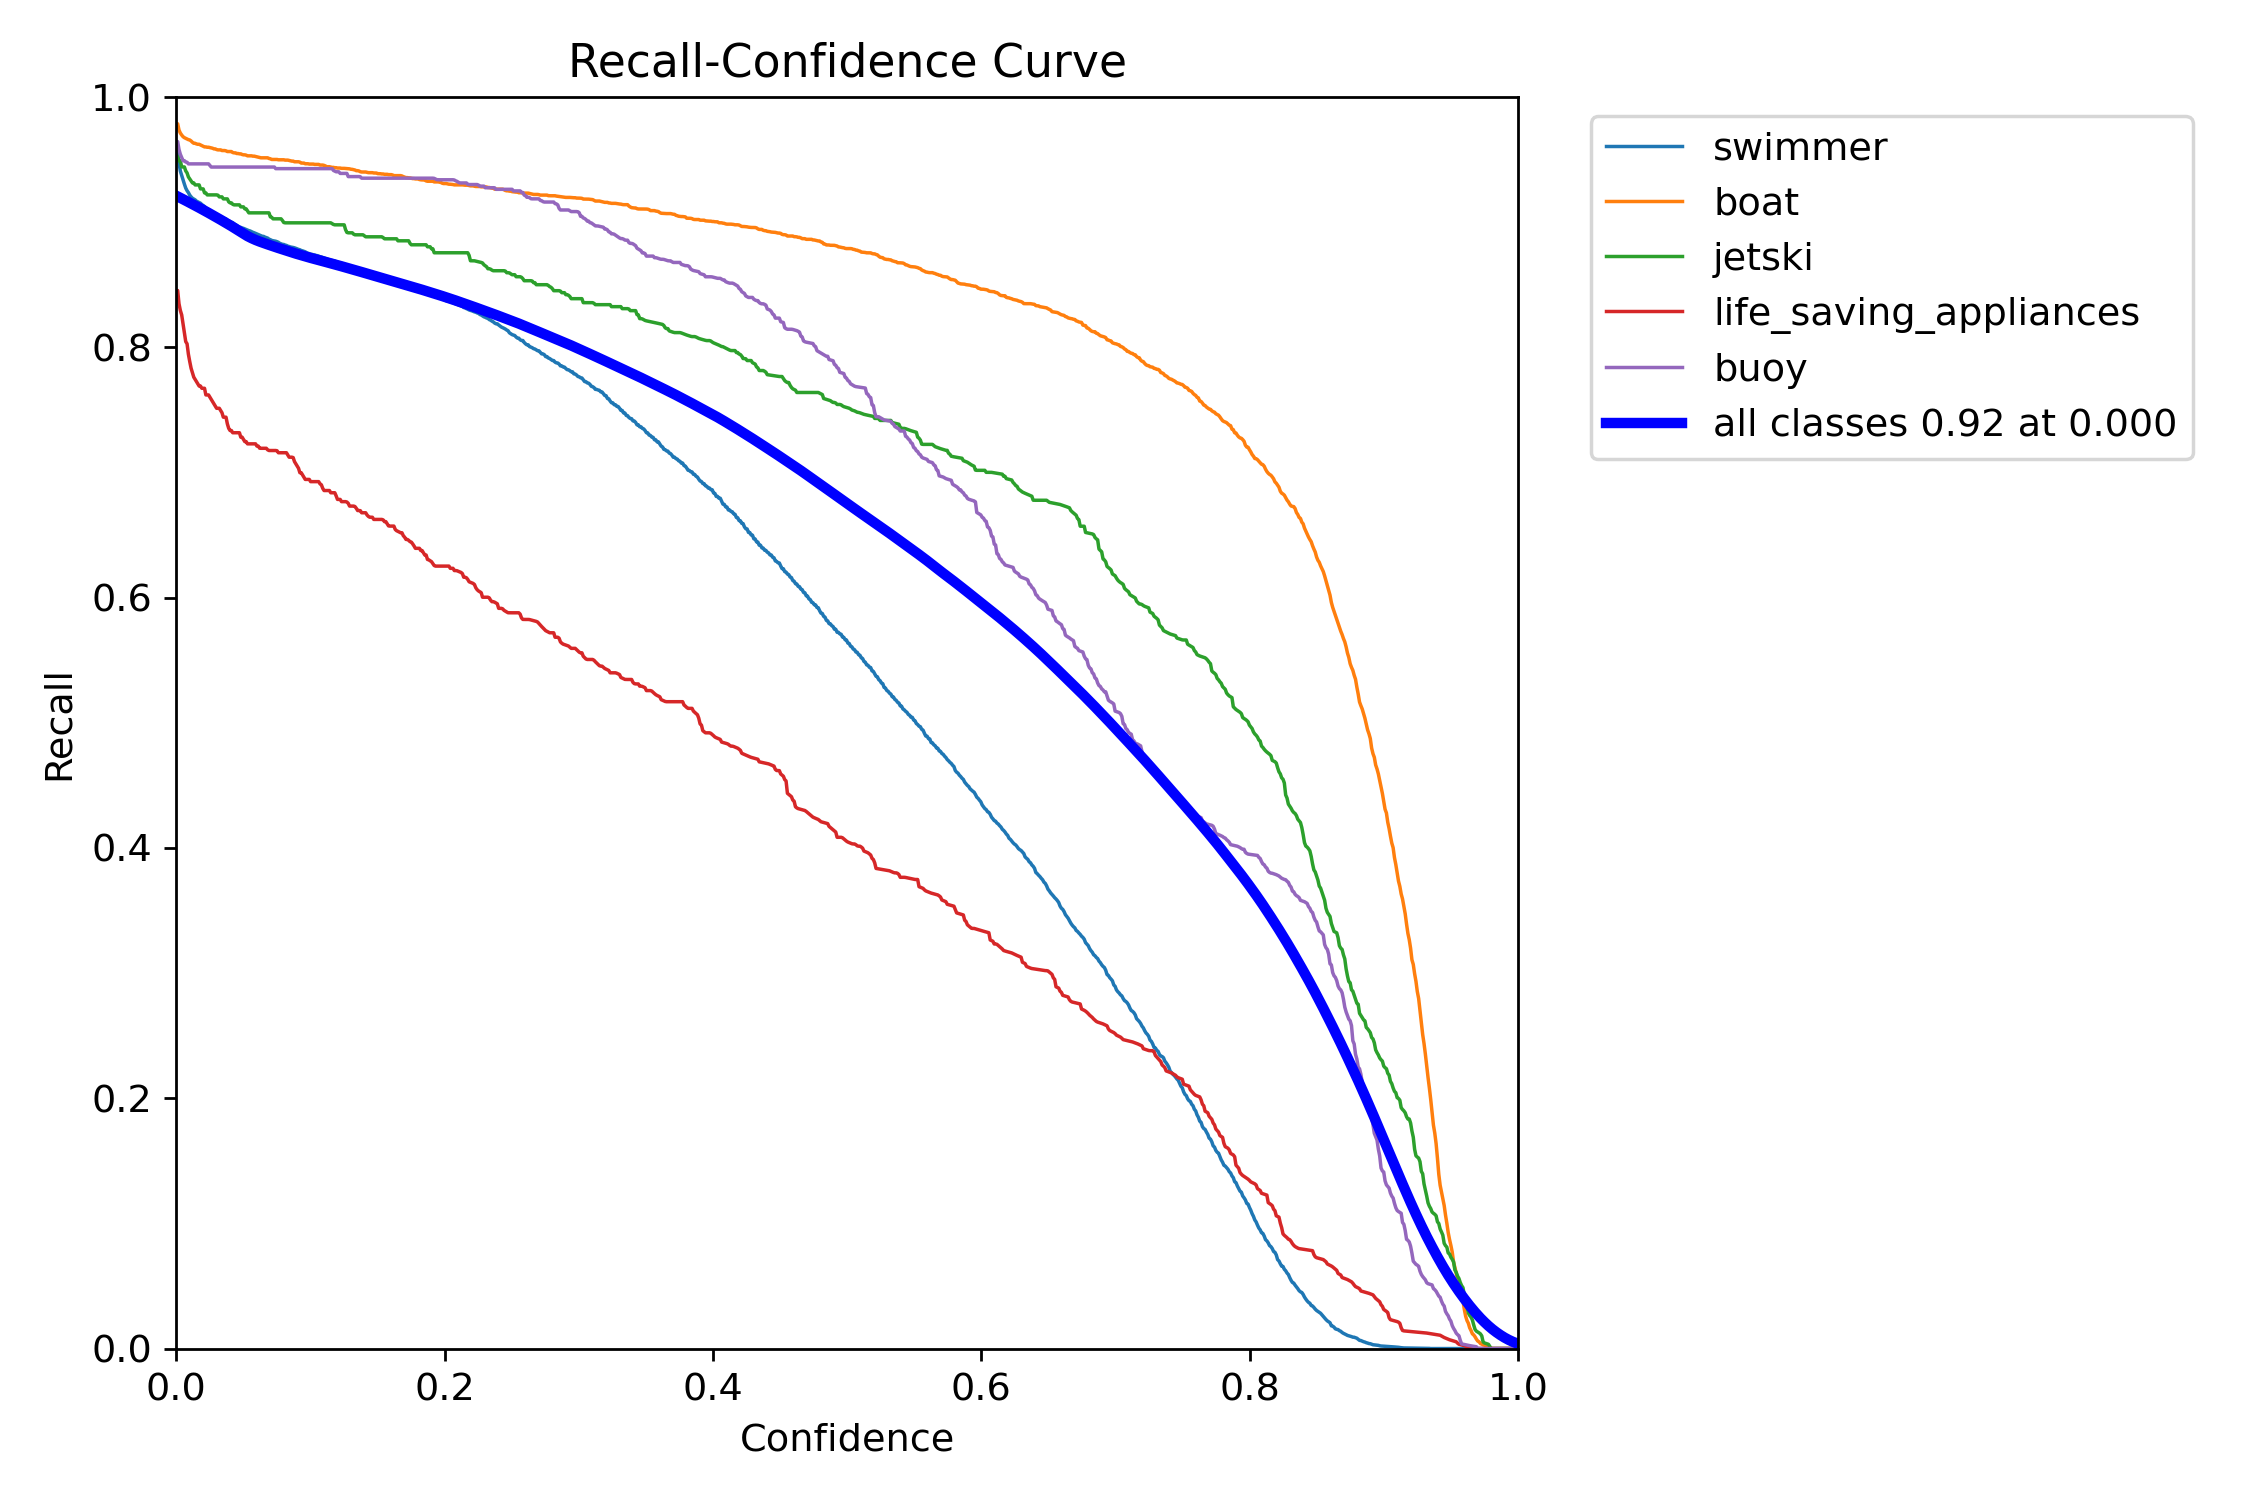

--------------------------------------------------------------------------------
Showing: confusion_matrix.png


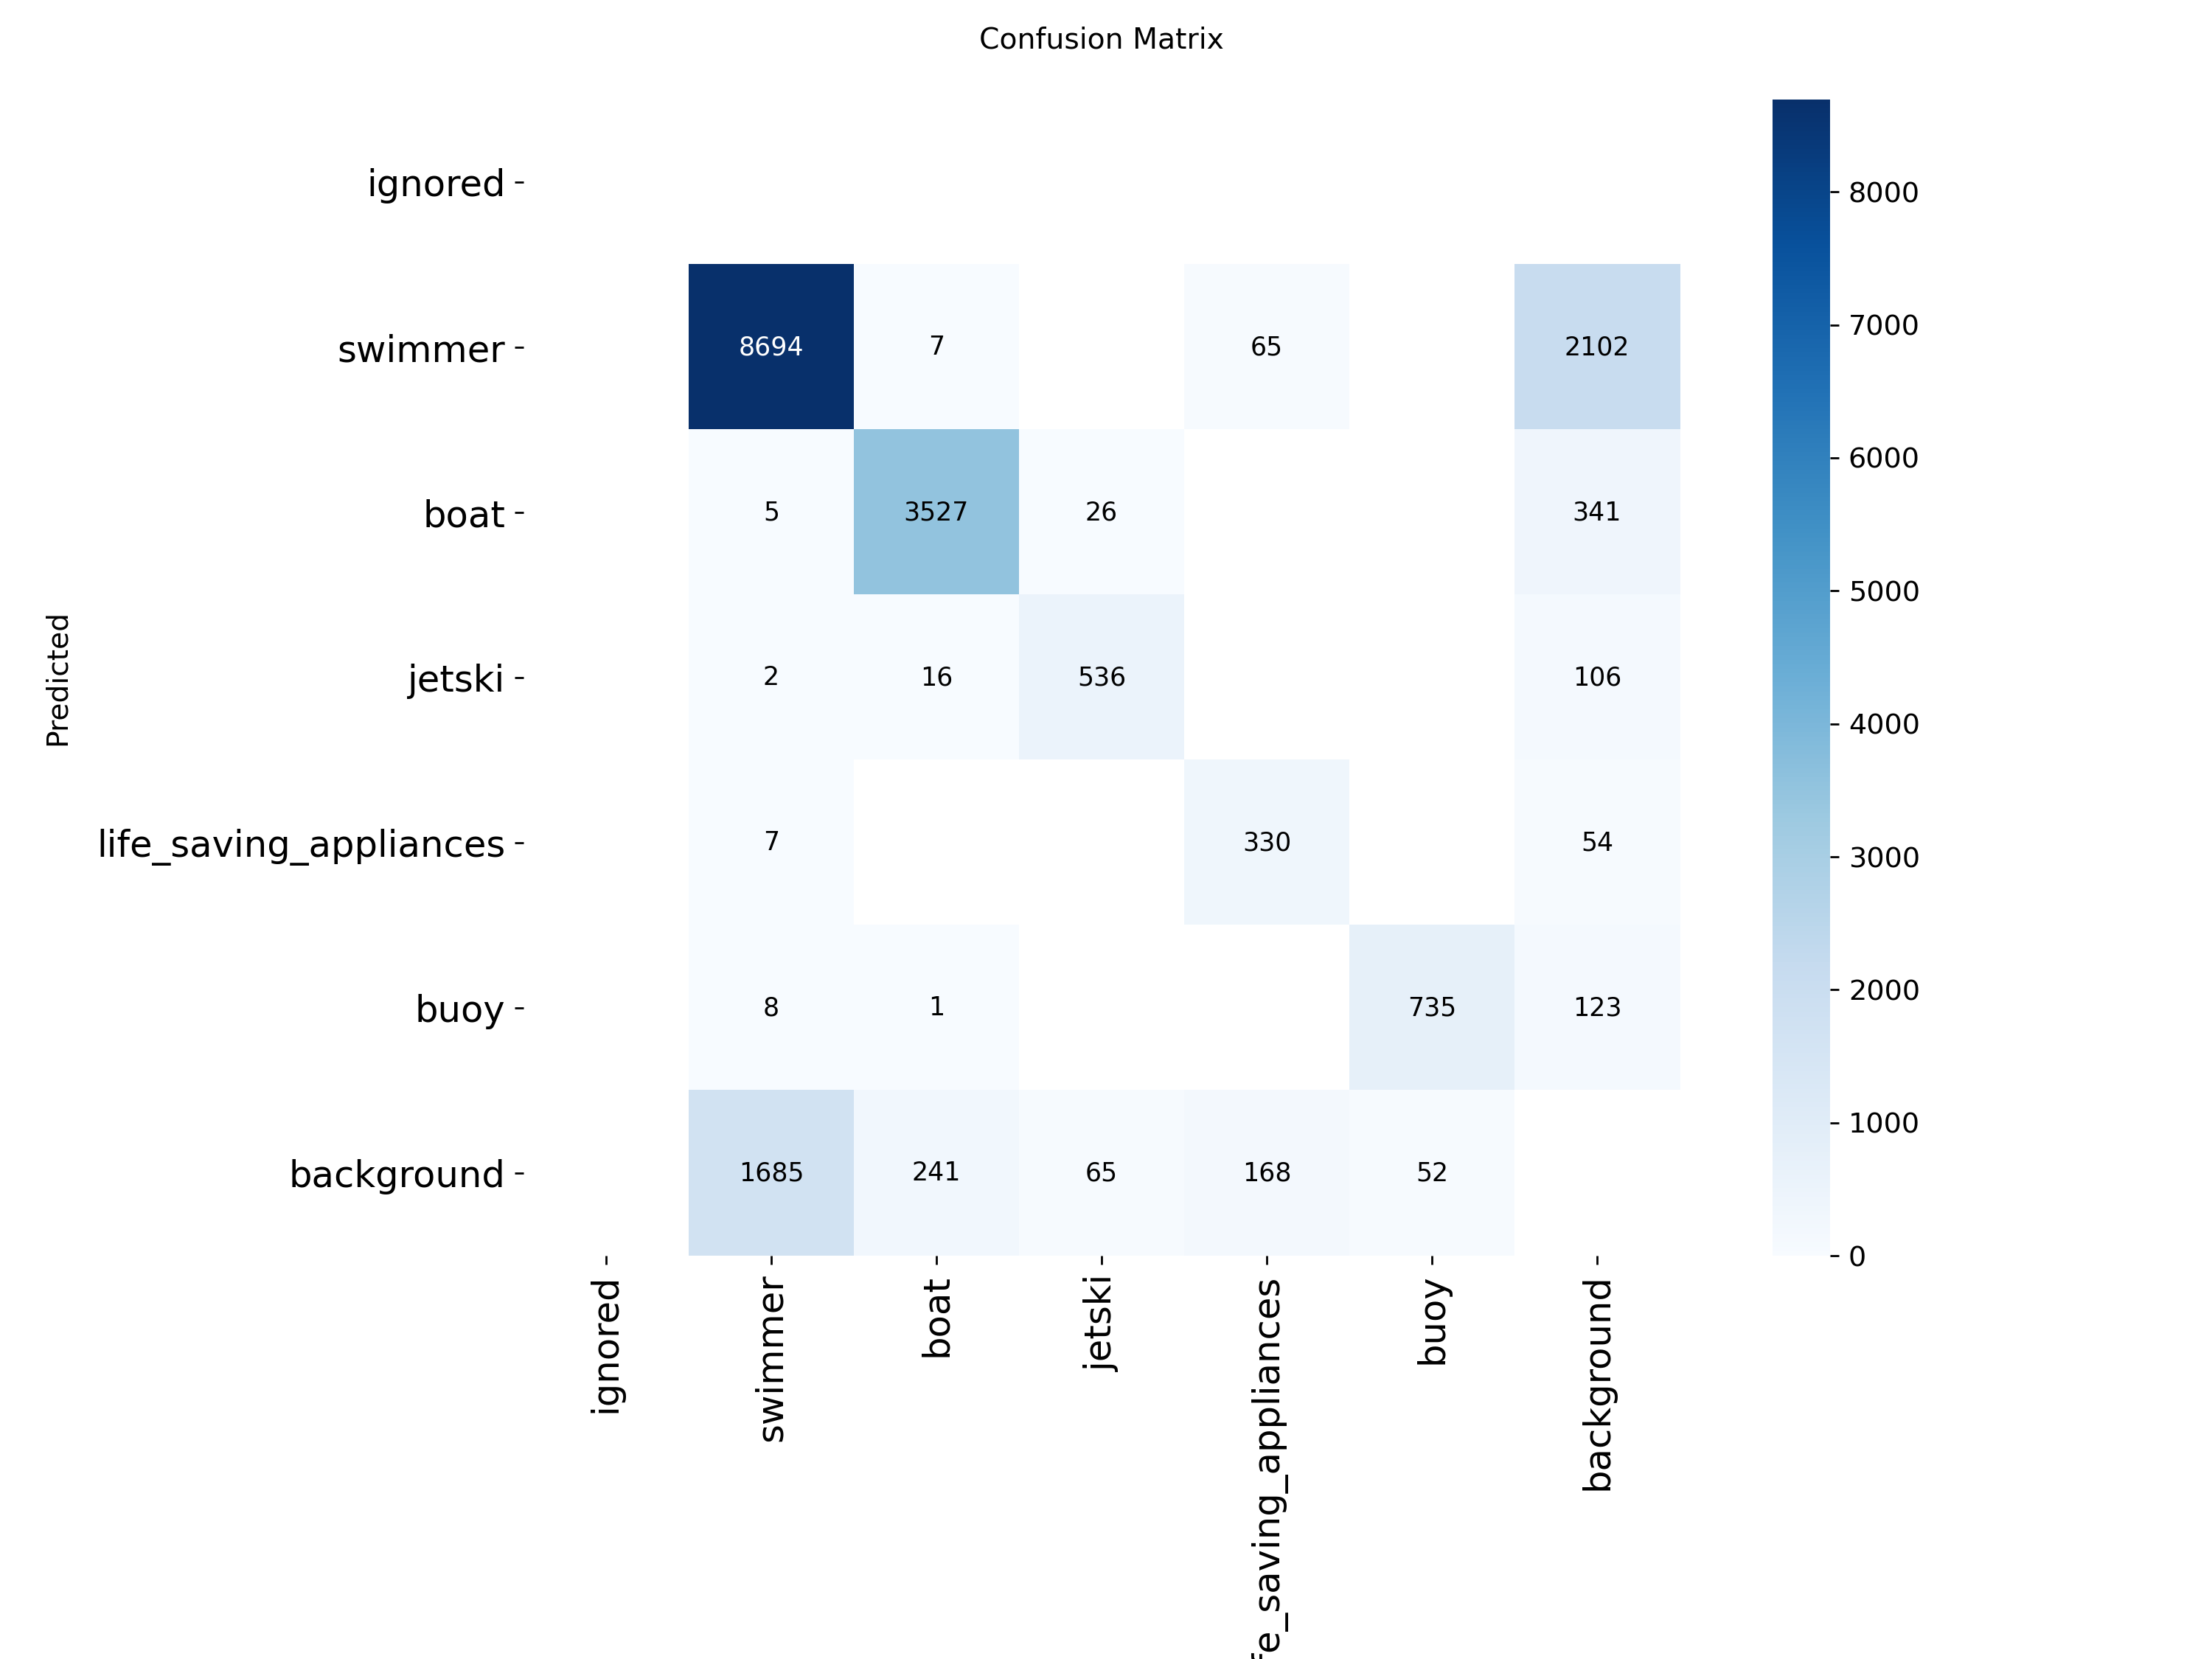

--------------------------------------------------------------------------------
Showing: confusion_matrix_normalized.png


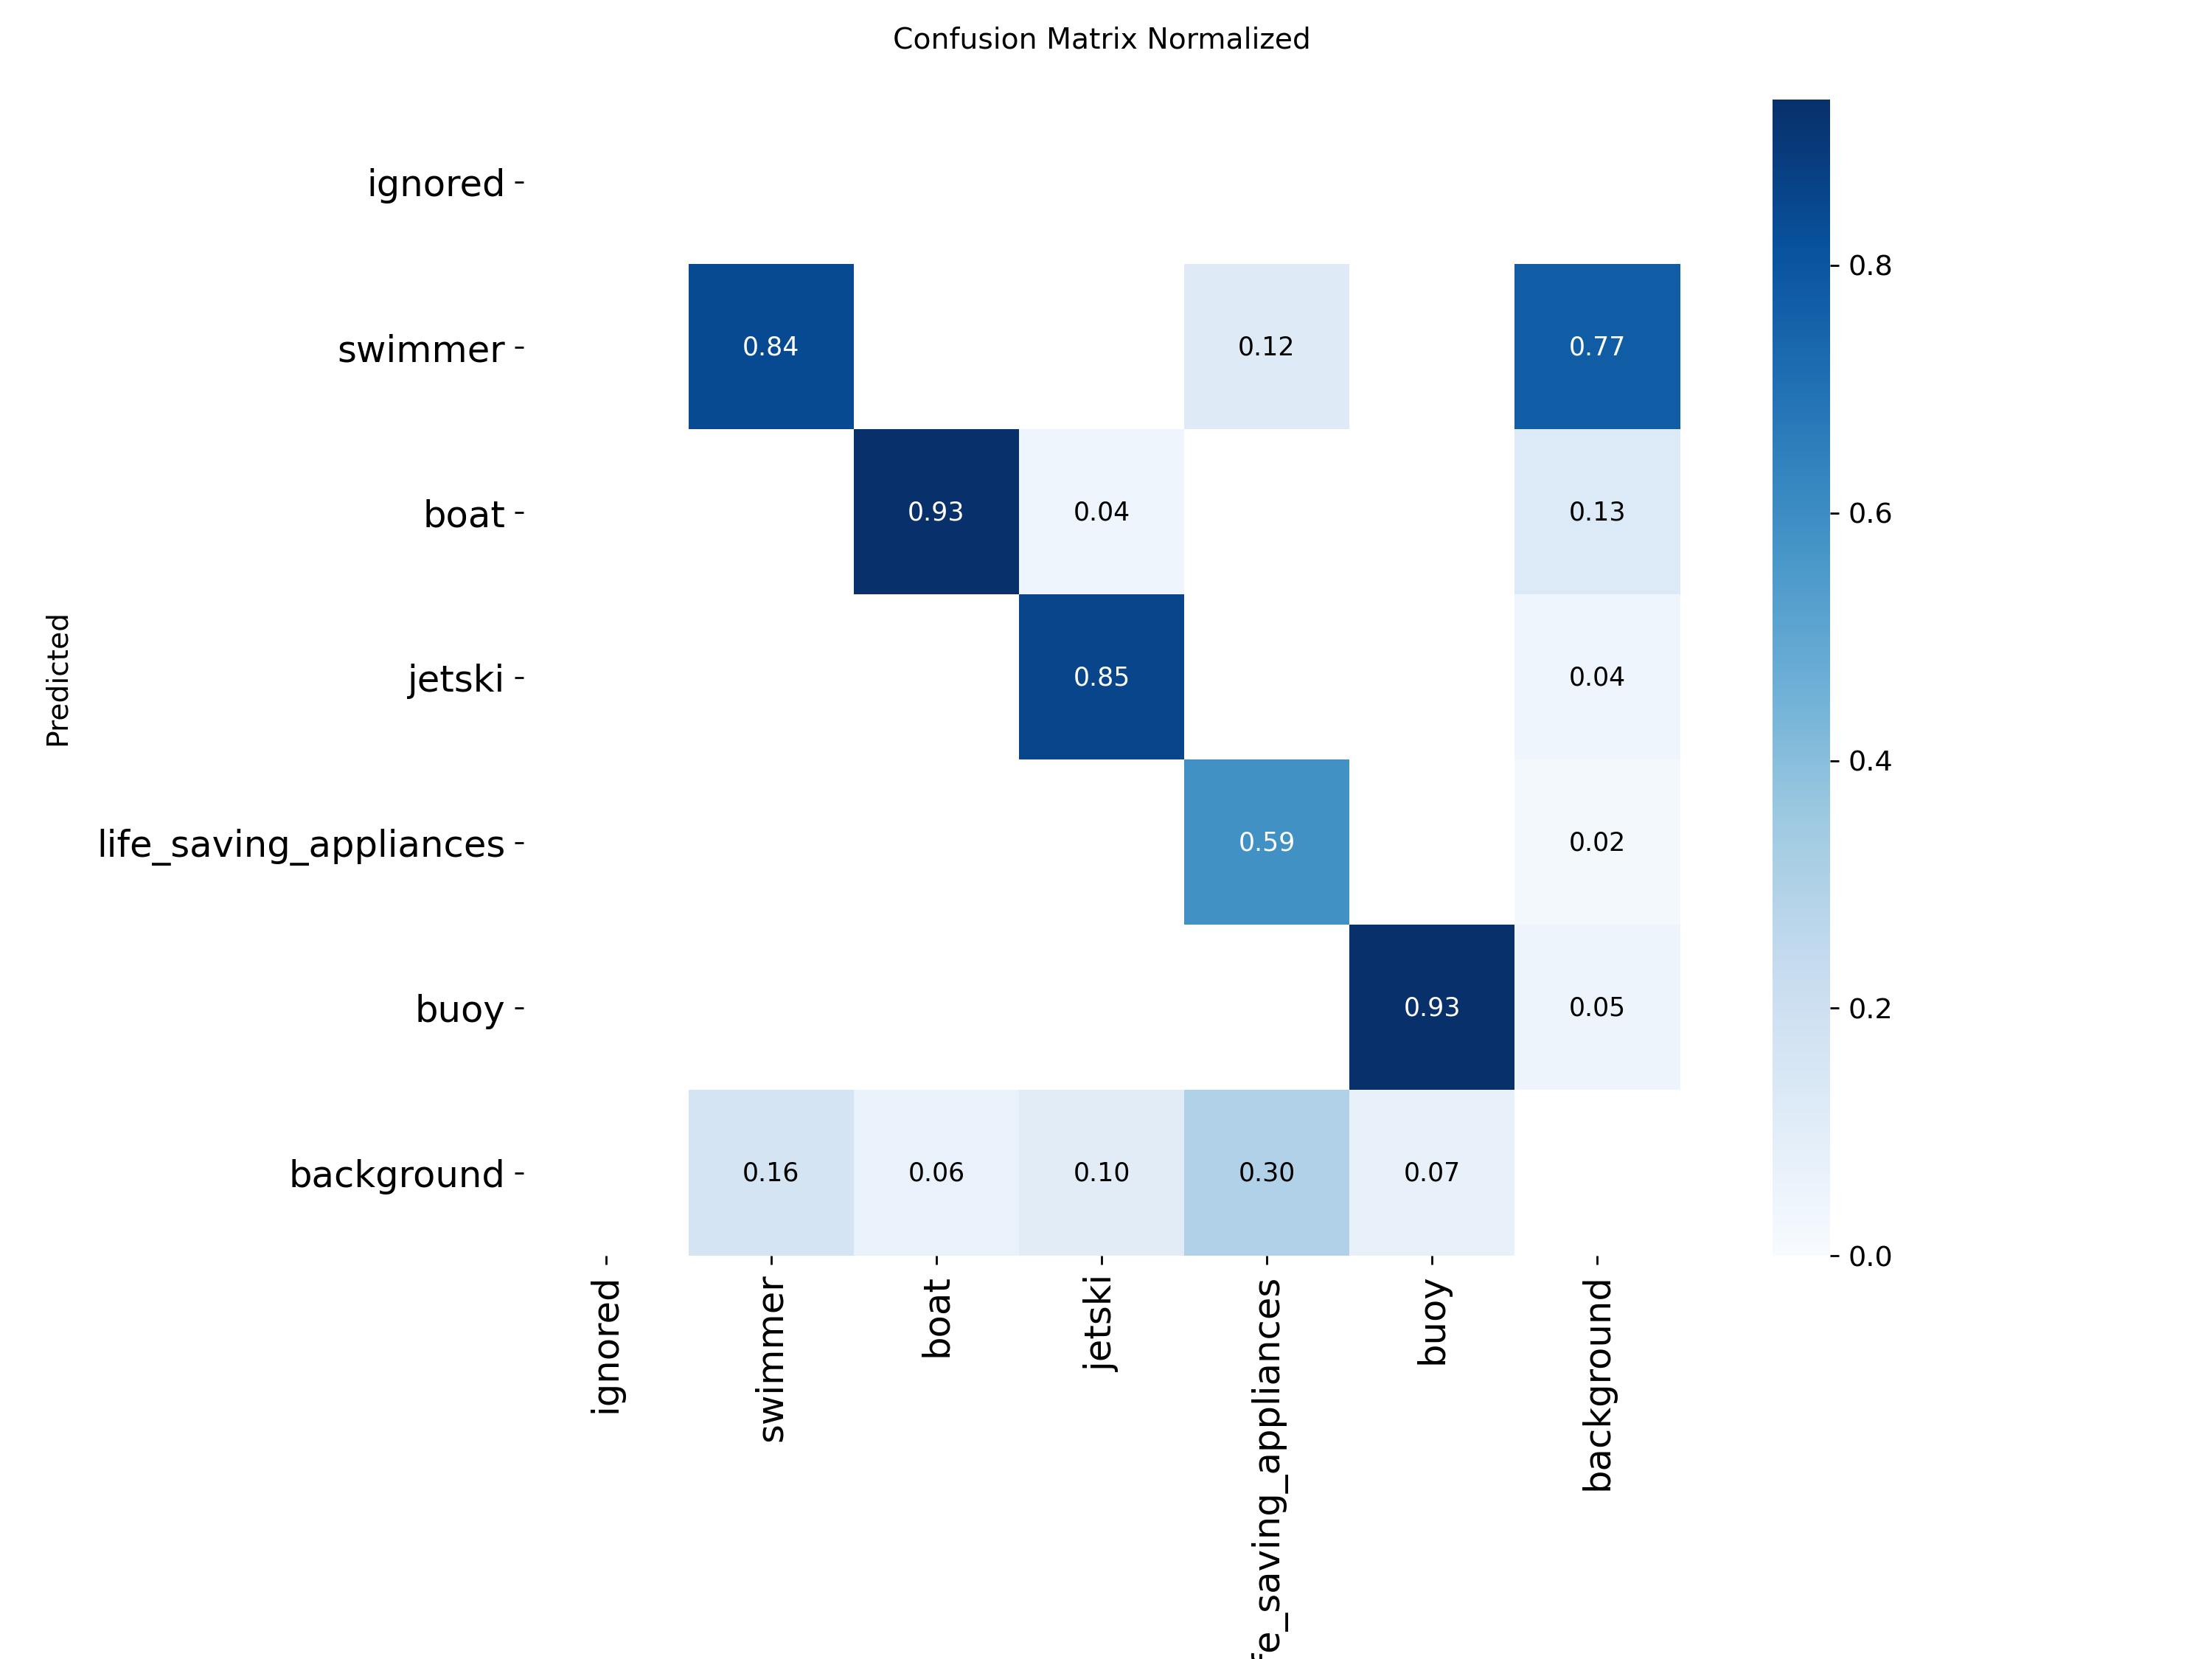

--------------------------------------------------------------------------------
Showing: labels.jpg


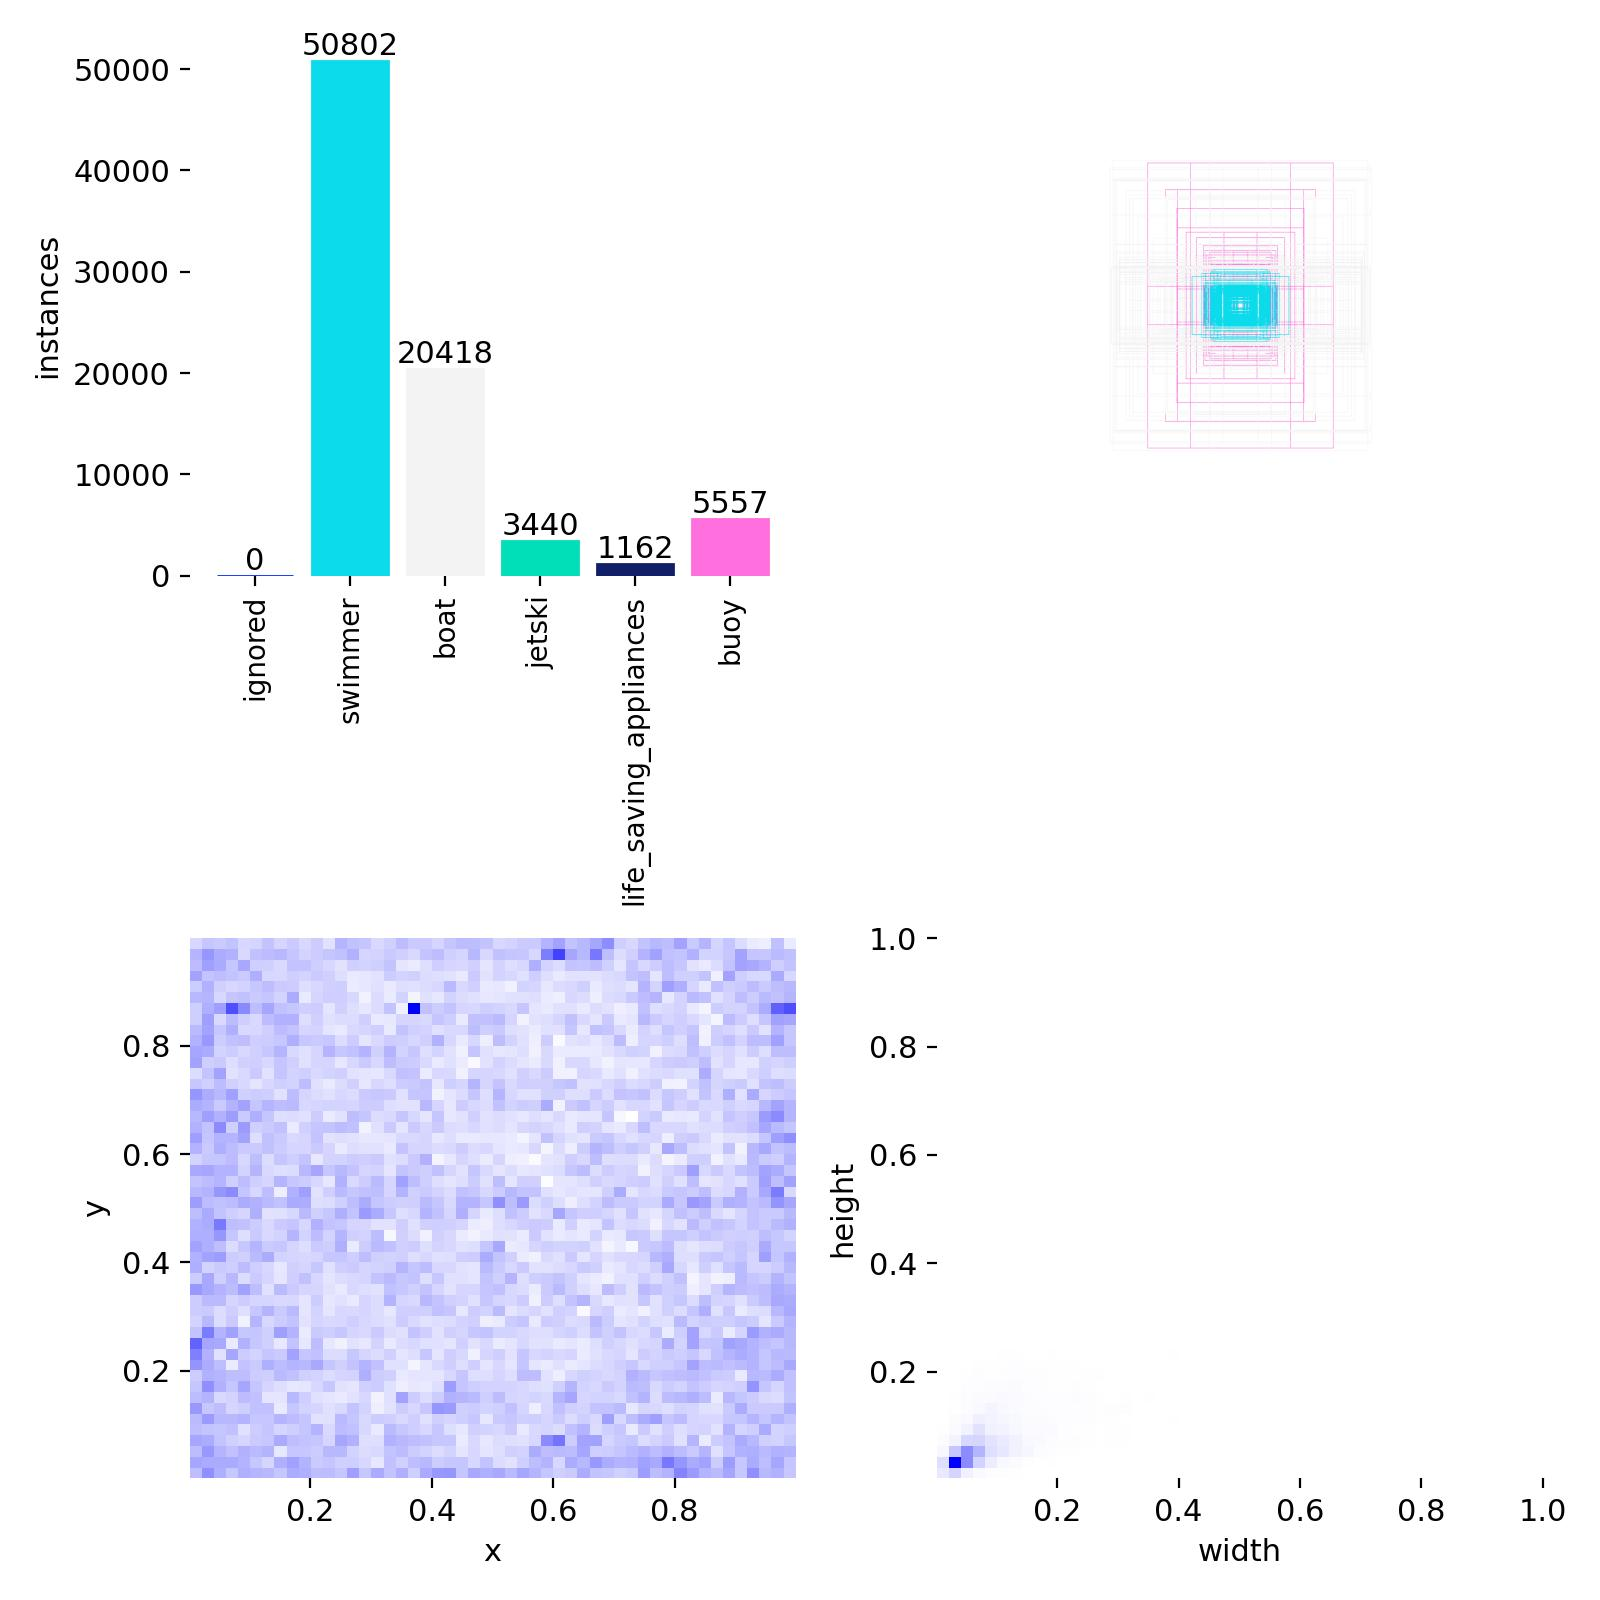

--------------------------------------------------------------------------------
Showing: results.png


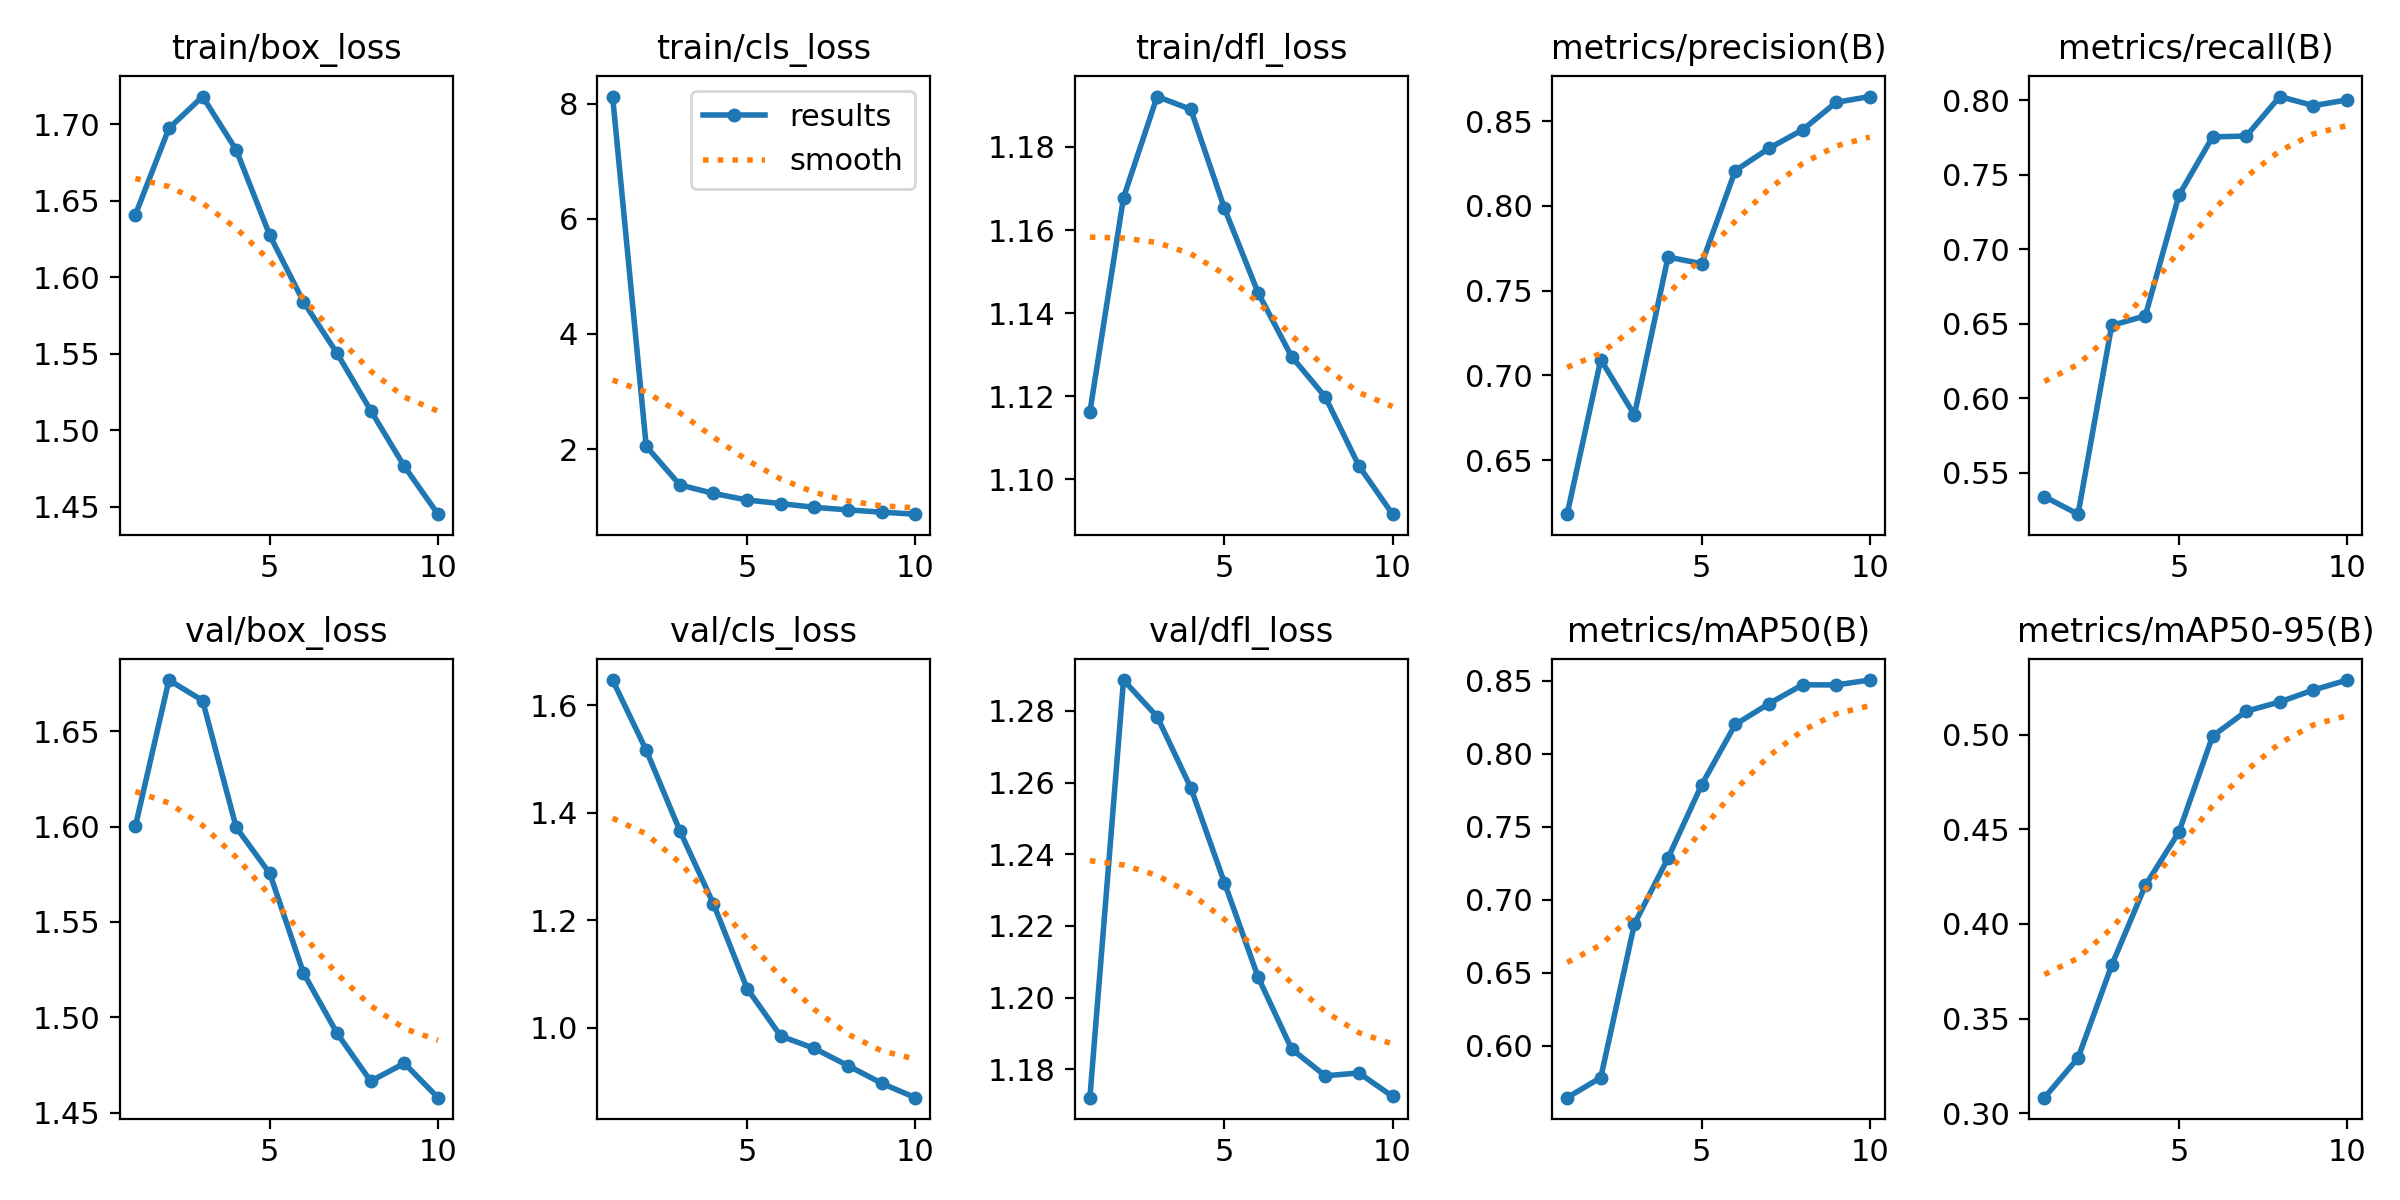

--------------------------------------------------------------------------------
Showing: train_batch0.jpg


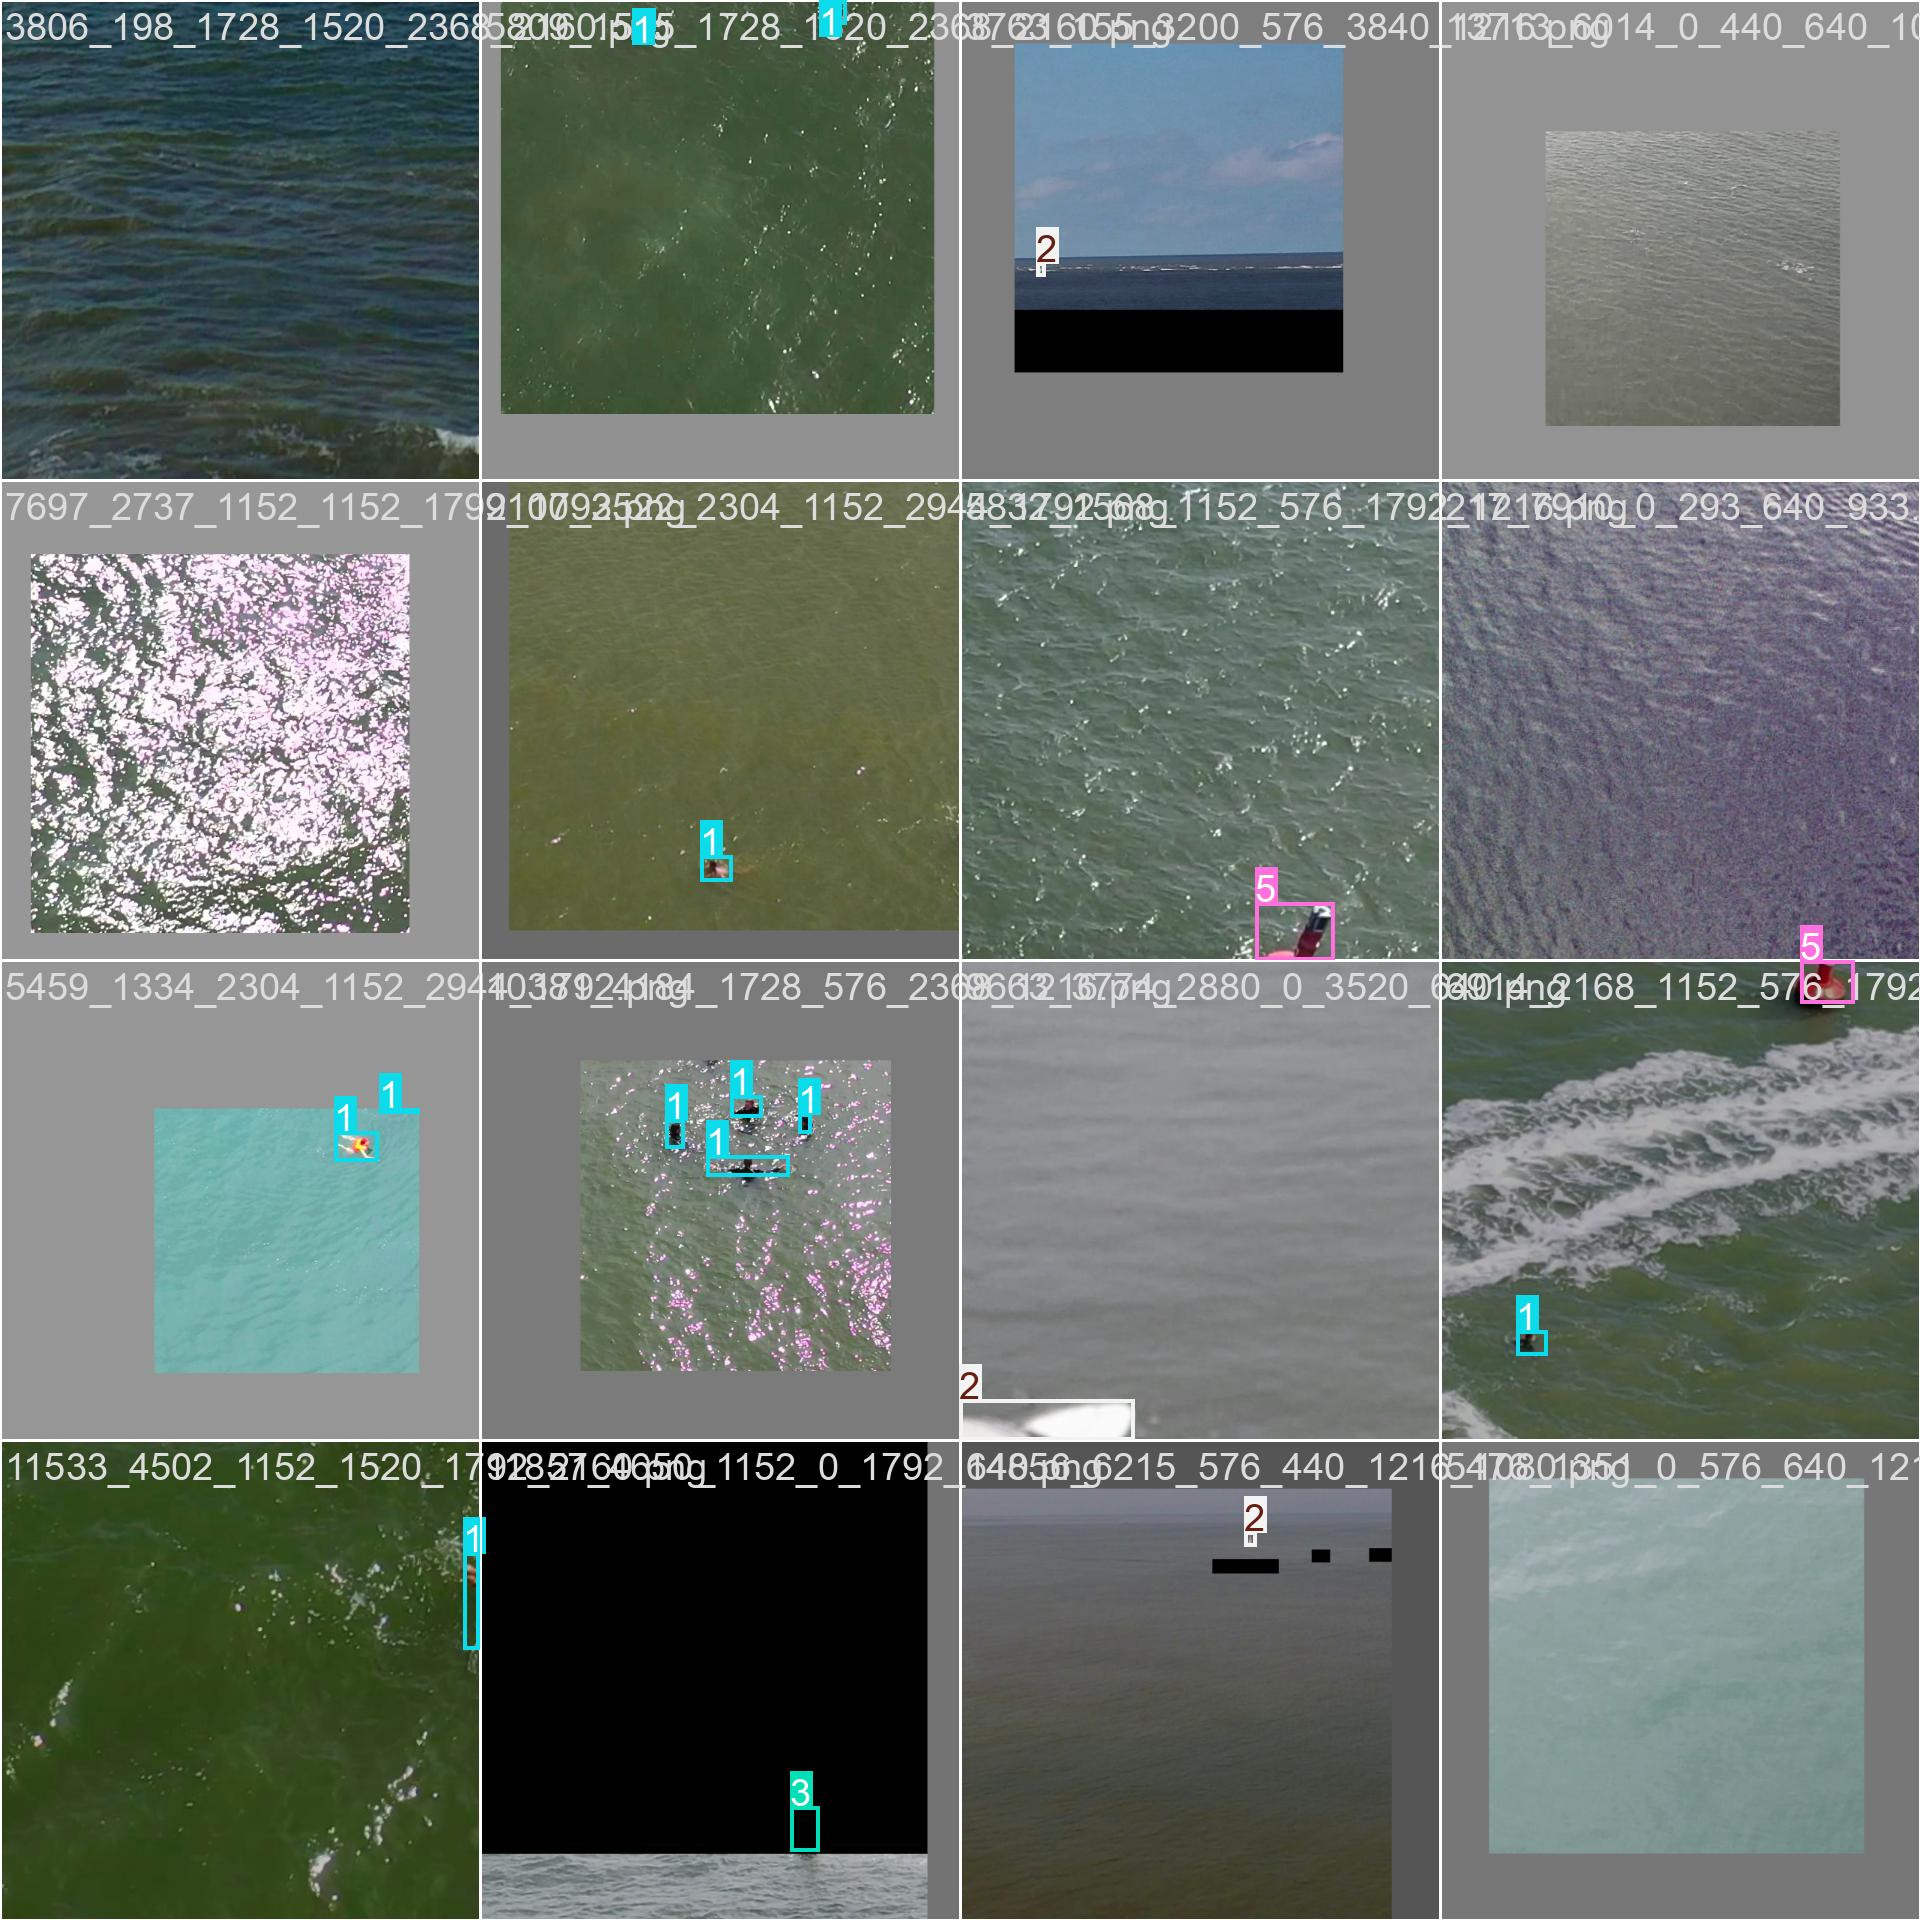

--------------------------------------------------------------------------------
Showing: train_batch1.jpg


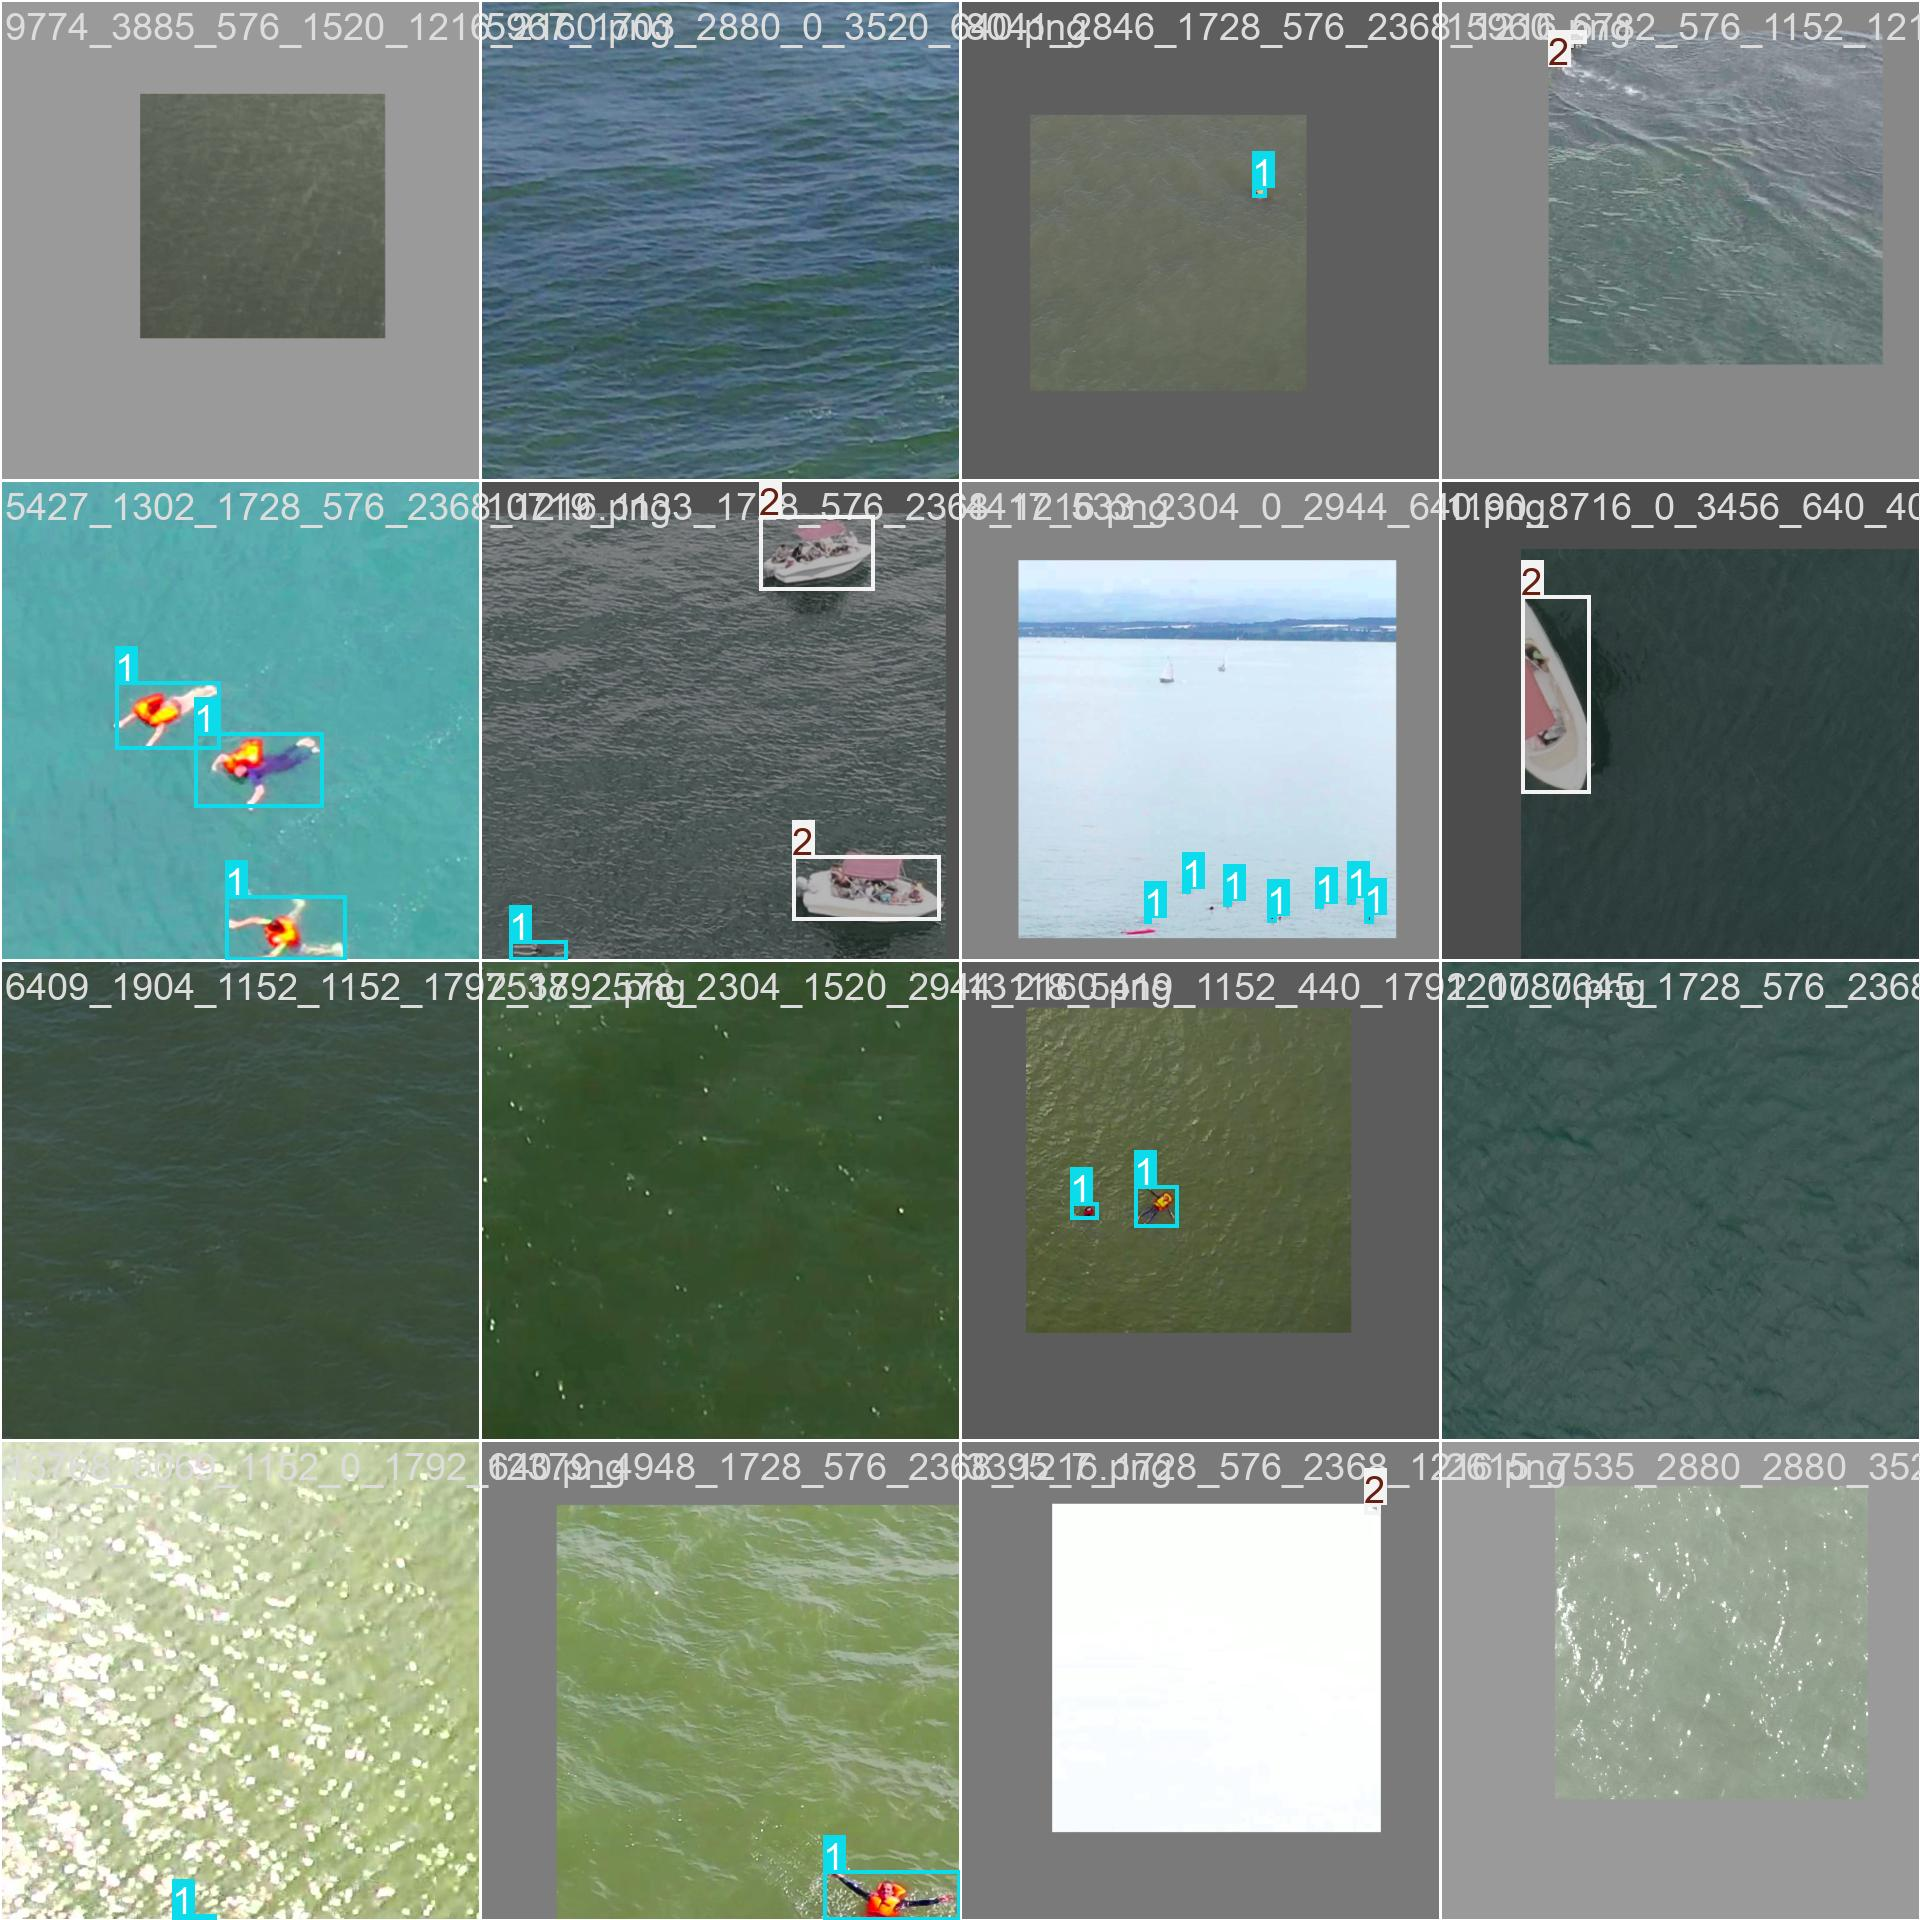

--------------------------------------------------------------------------------
Showing: train_batch2.jpg


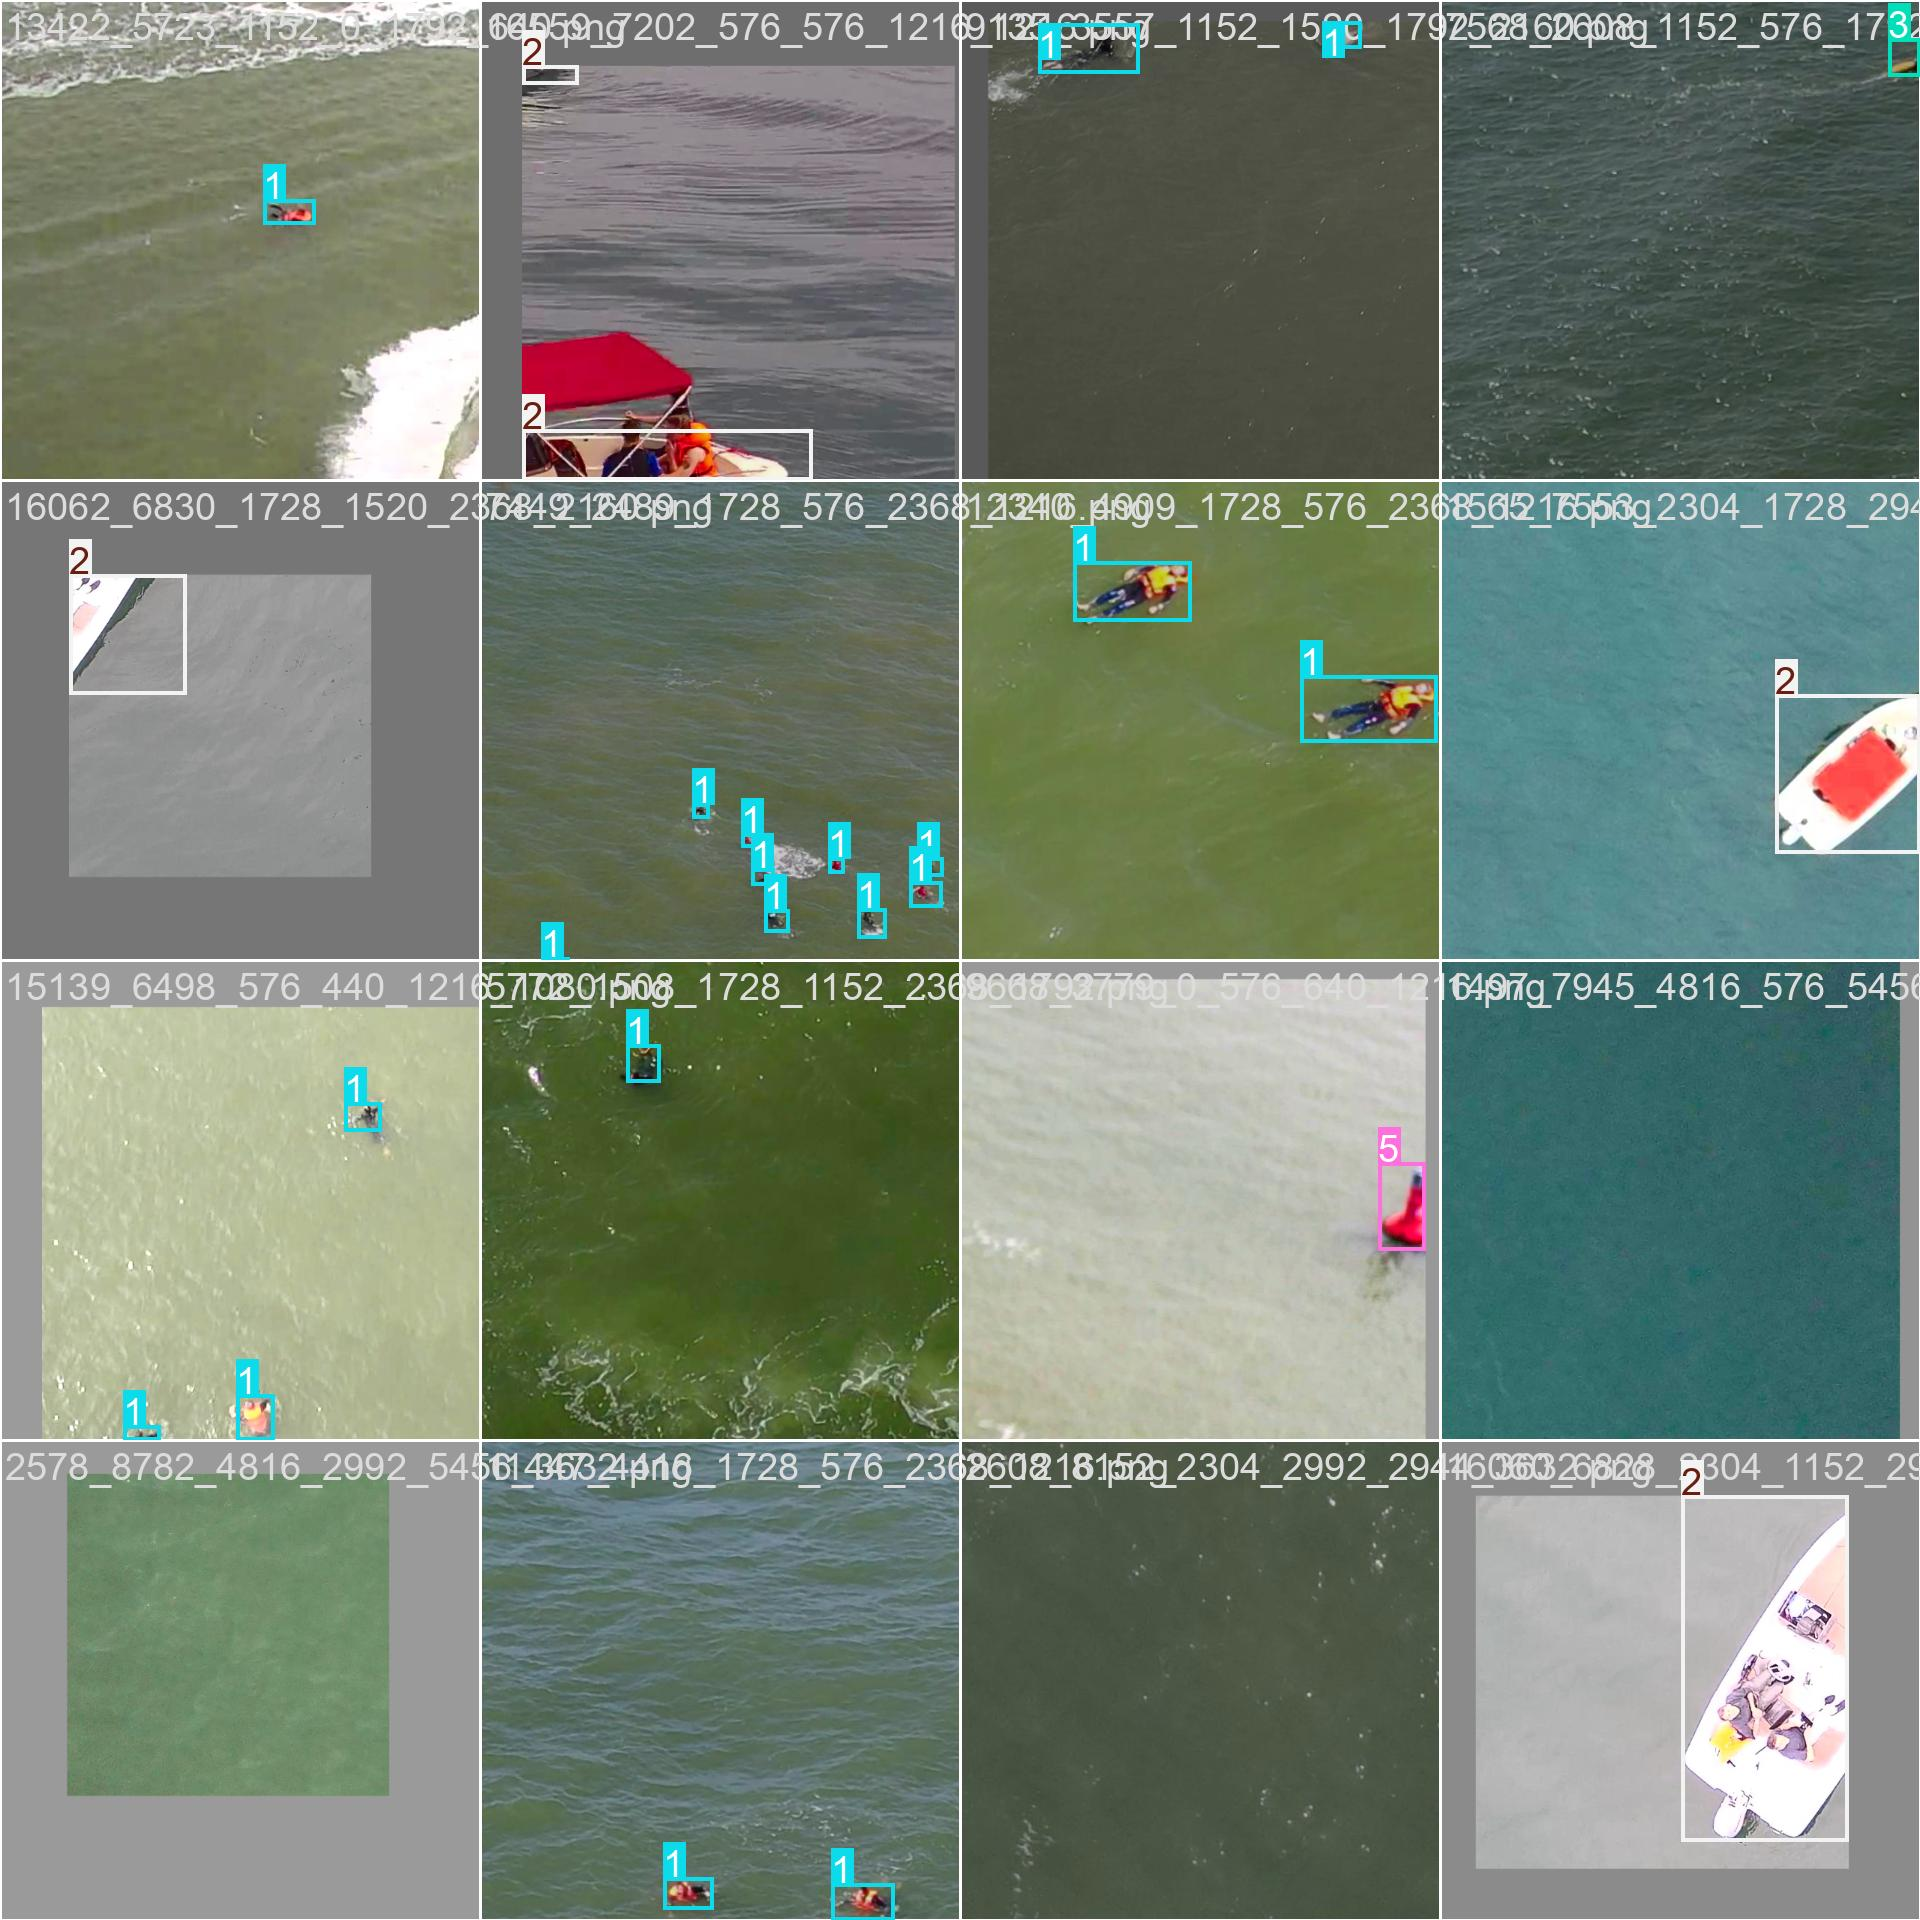

--------------------------------------------------------------------------------
Showing: val_batch0_labels.jpg


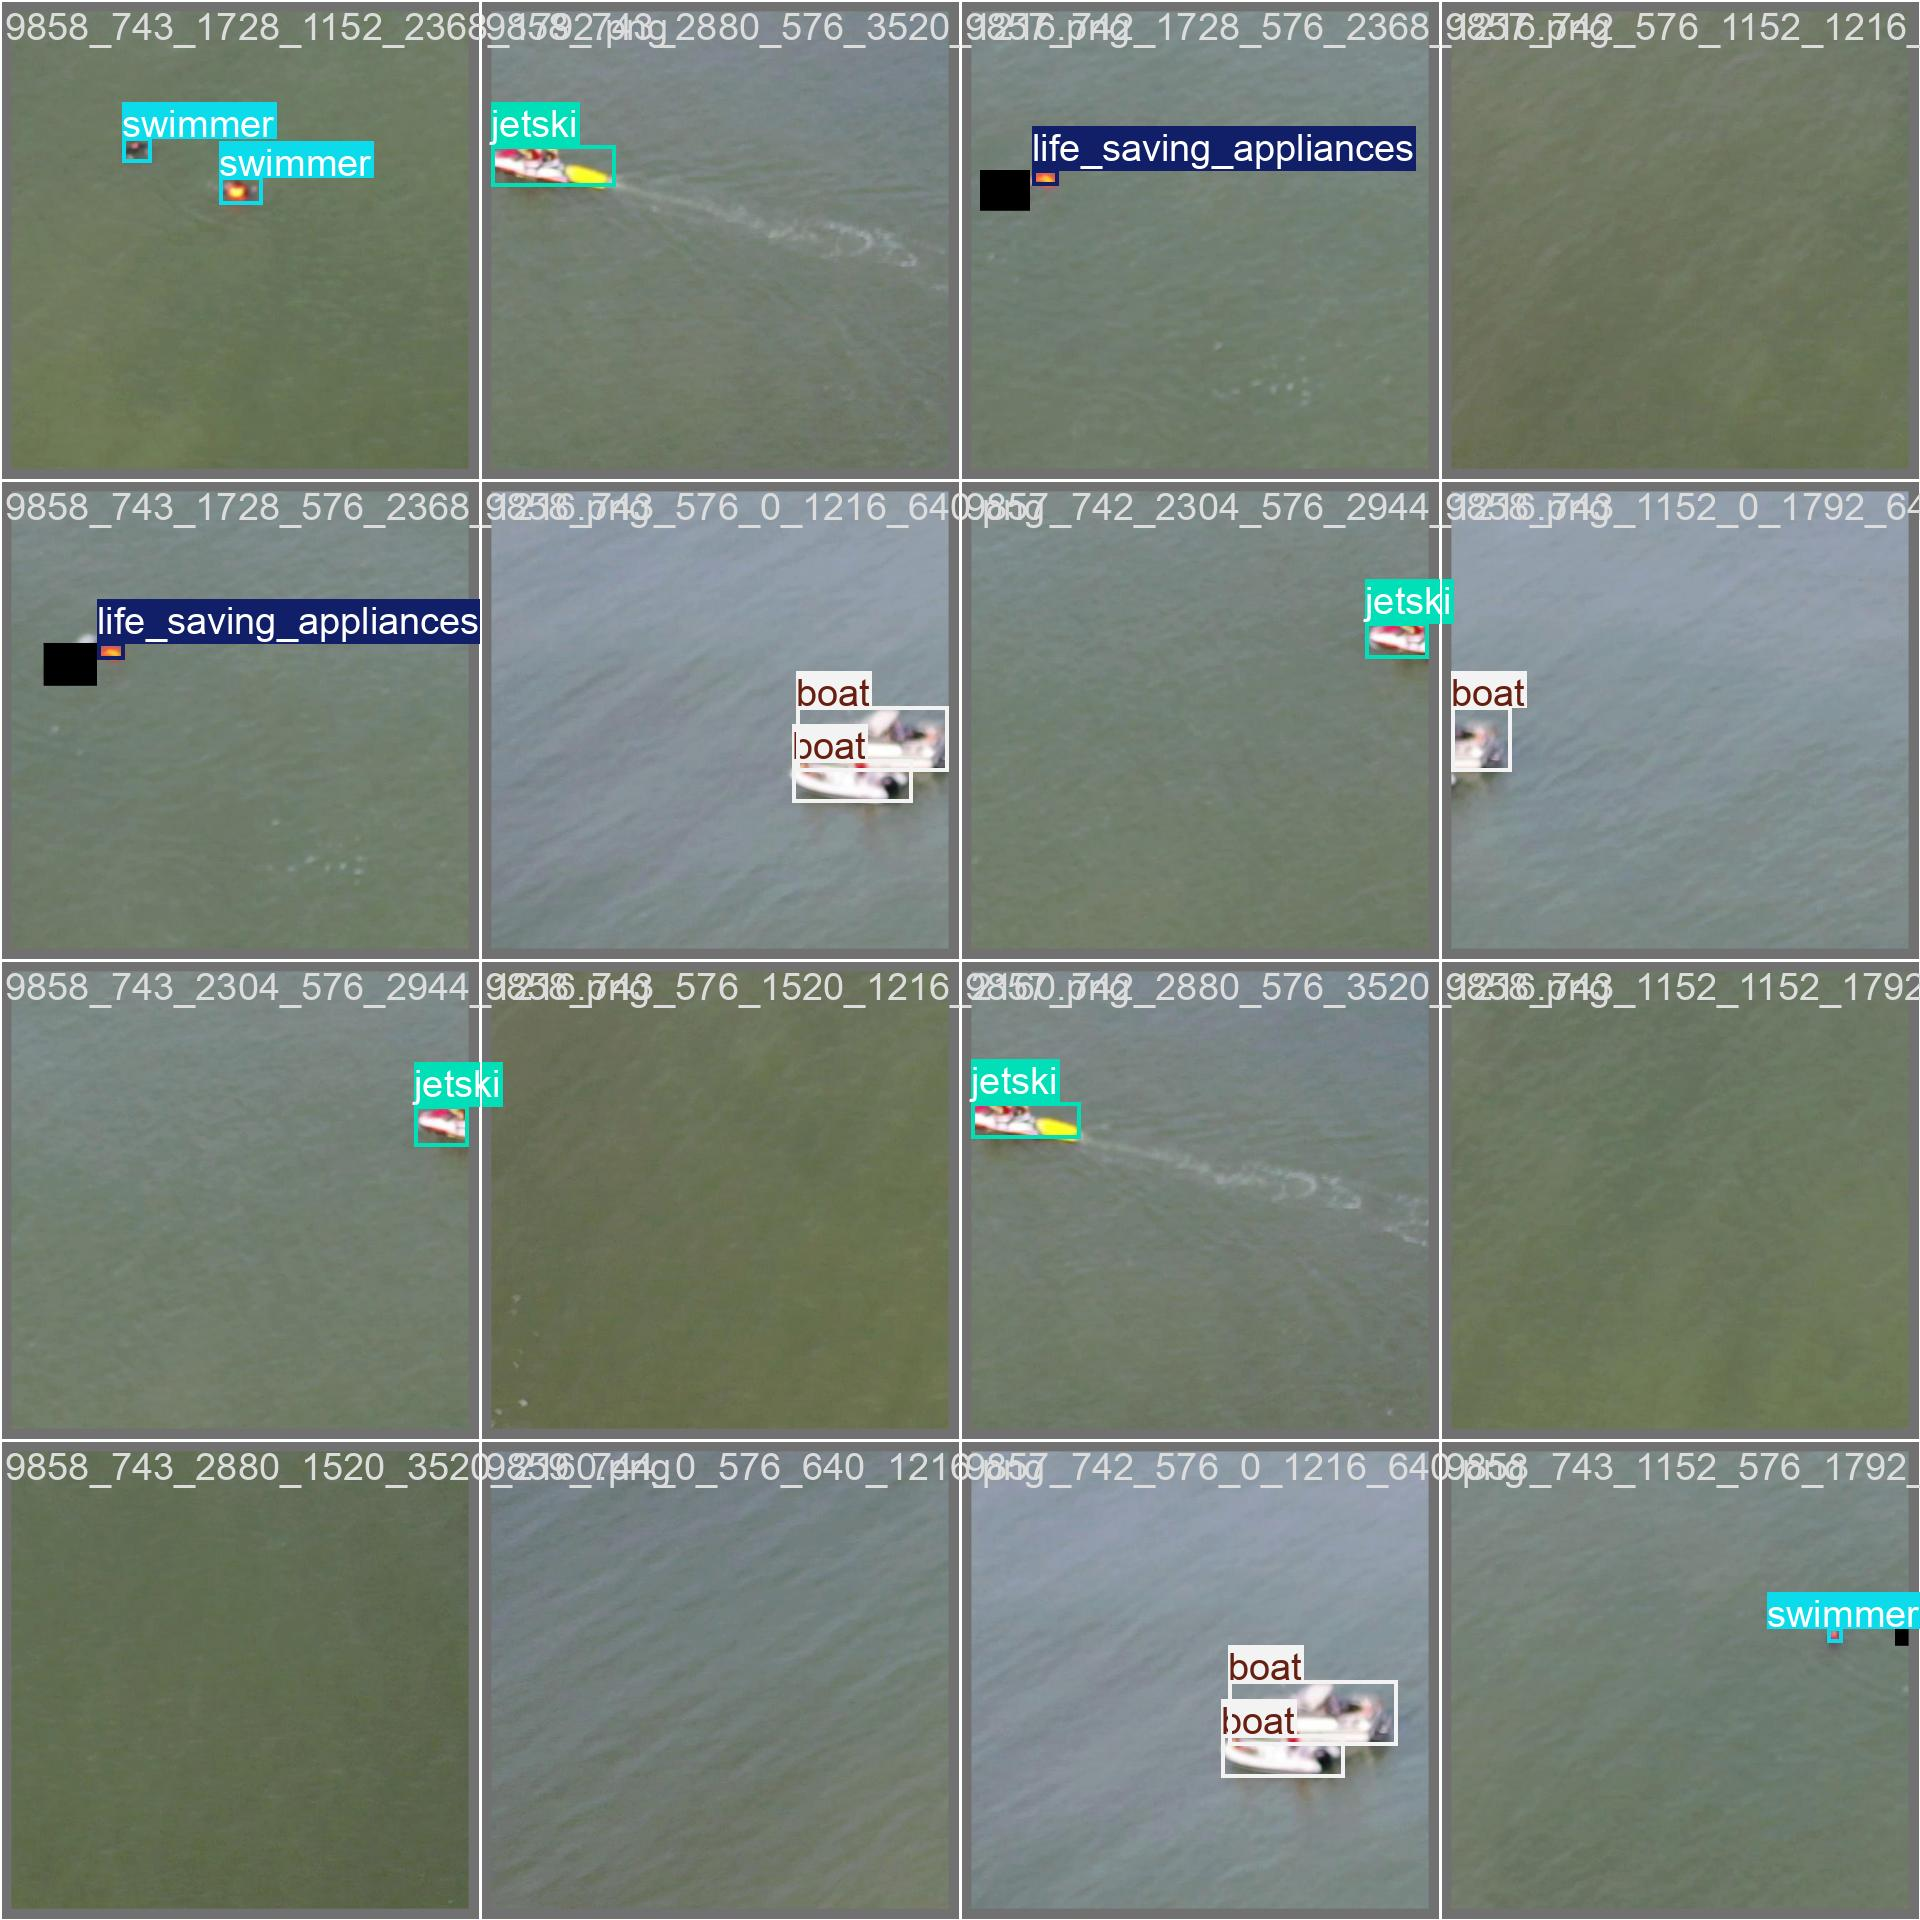

--------------------------------------------------------------------------------
Showing: val_batch0_pred.jpg


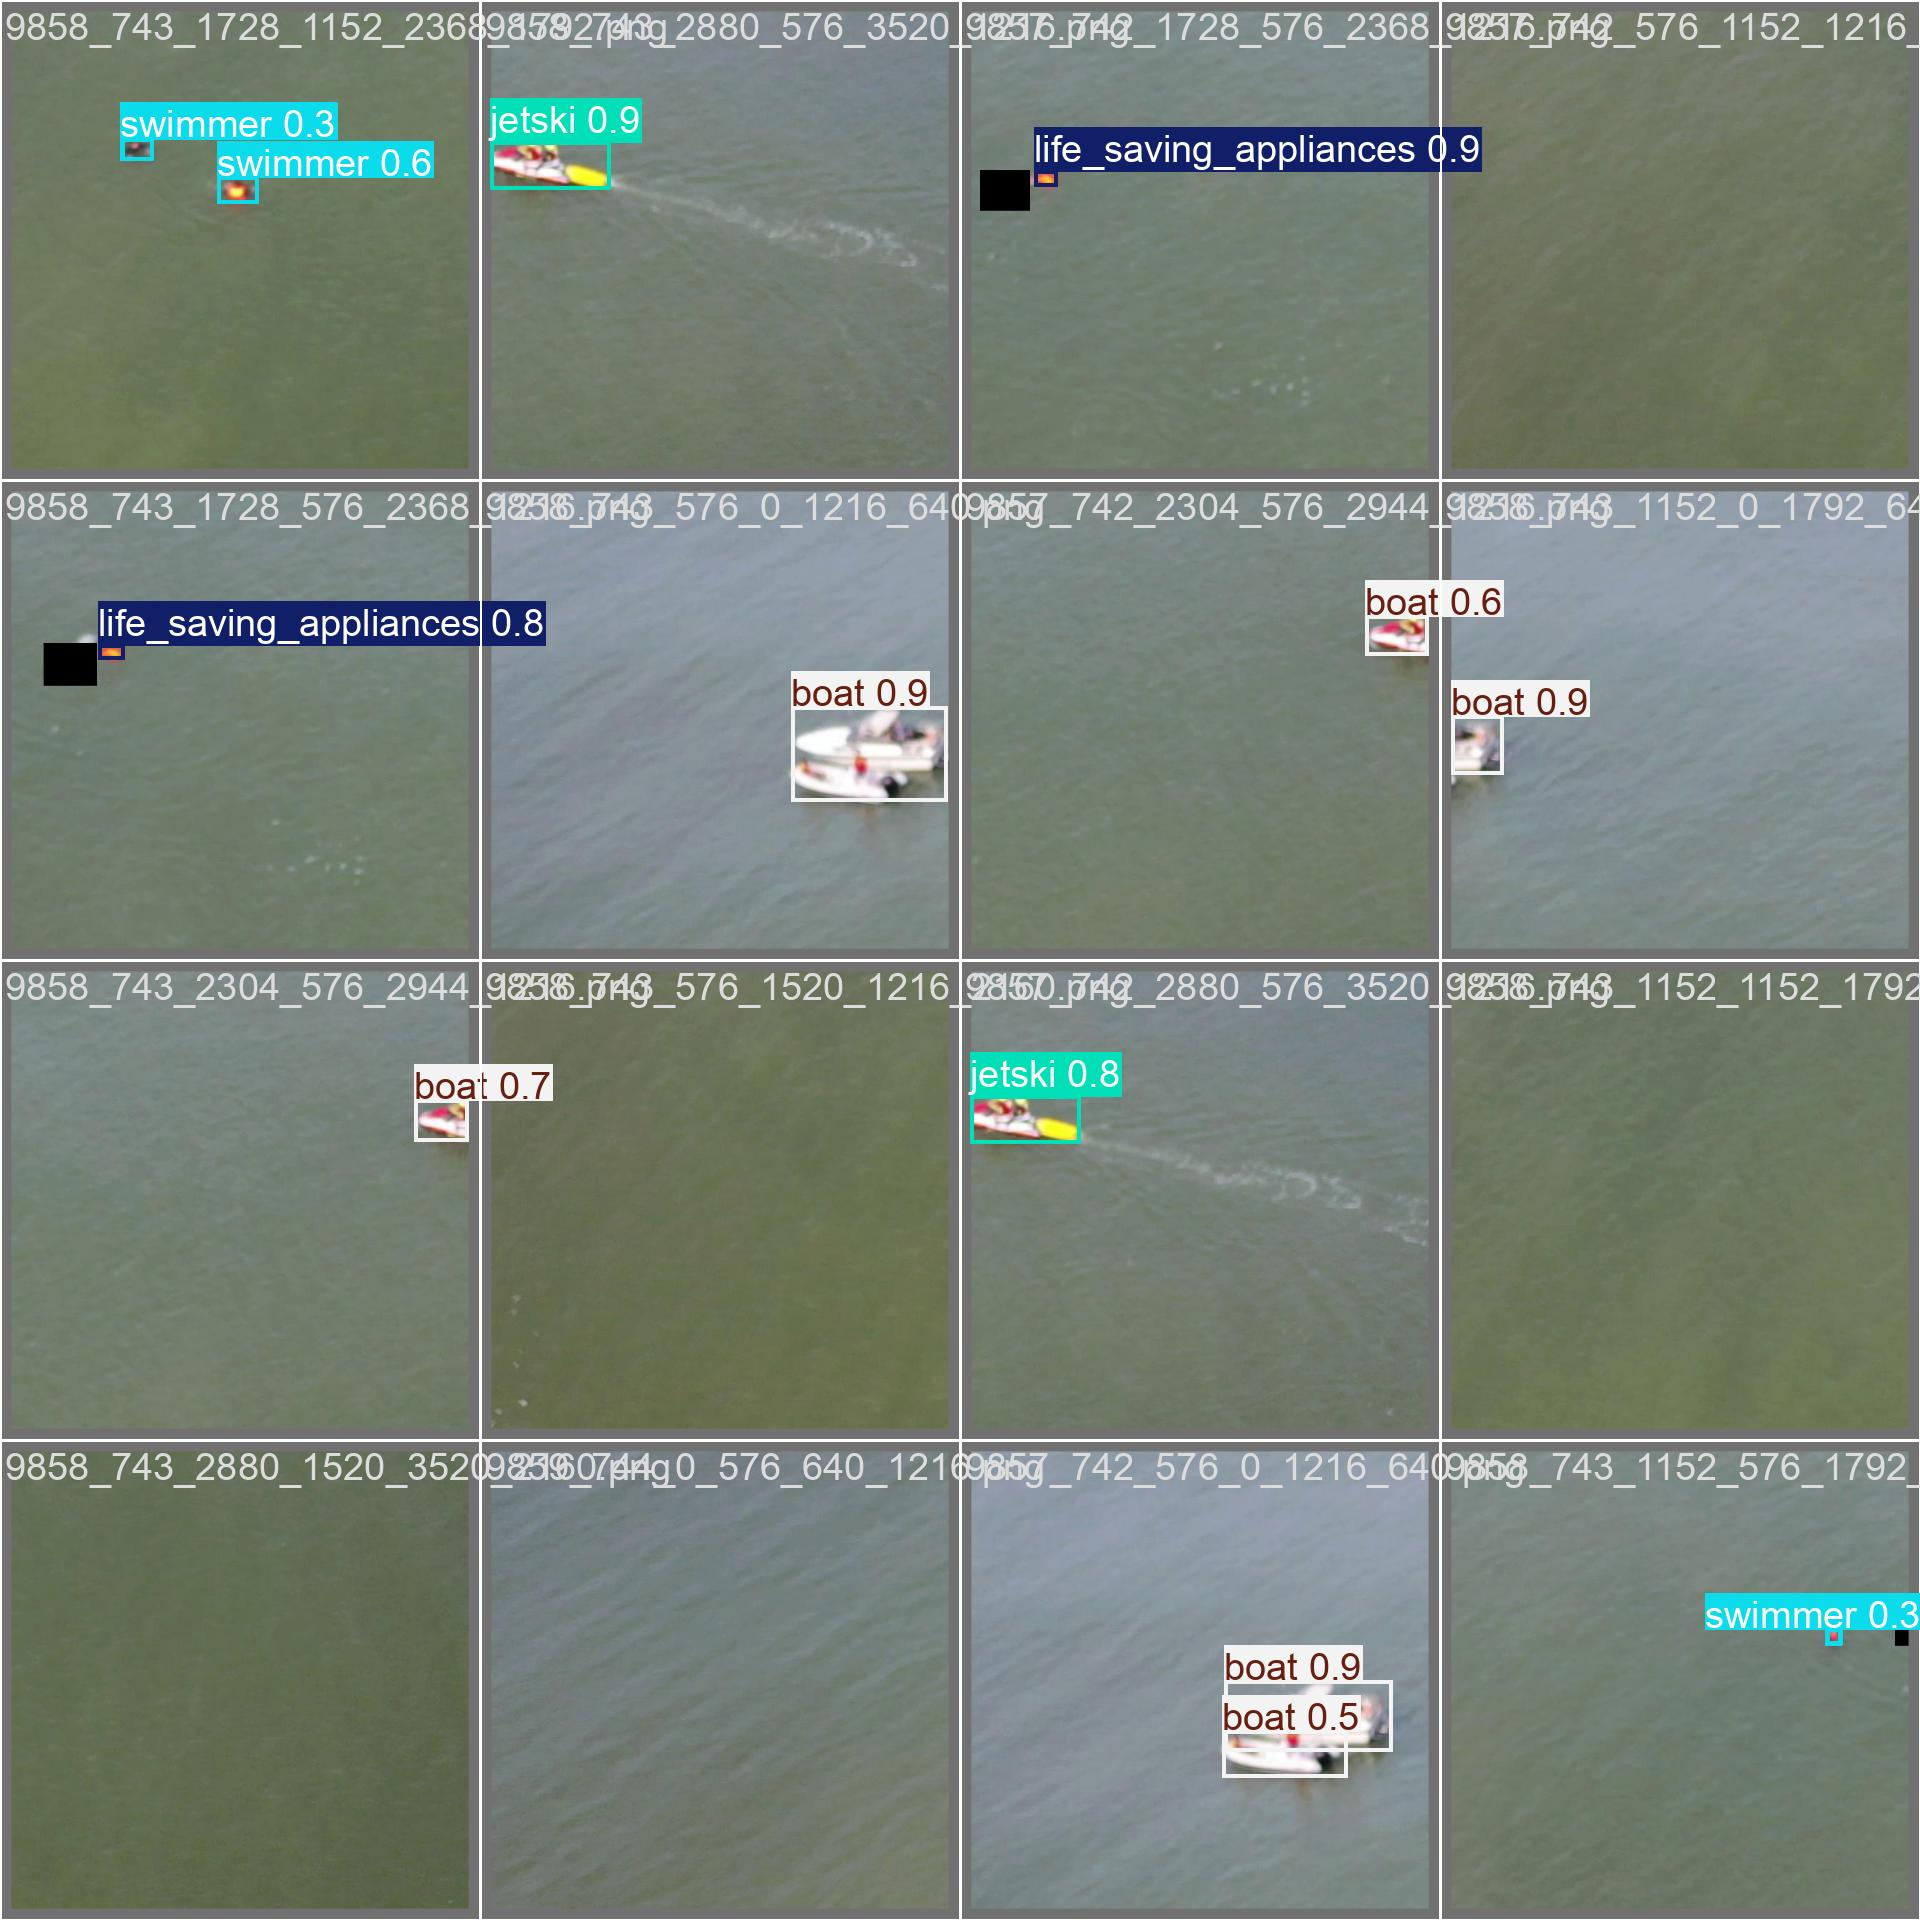

--------------------------------------------------------------------------------
Showing: val_batch1_labels.jpg


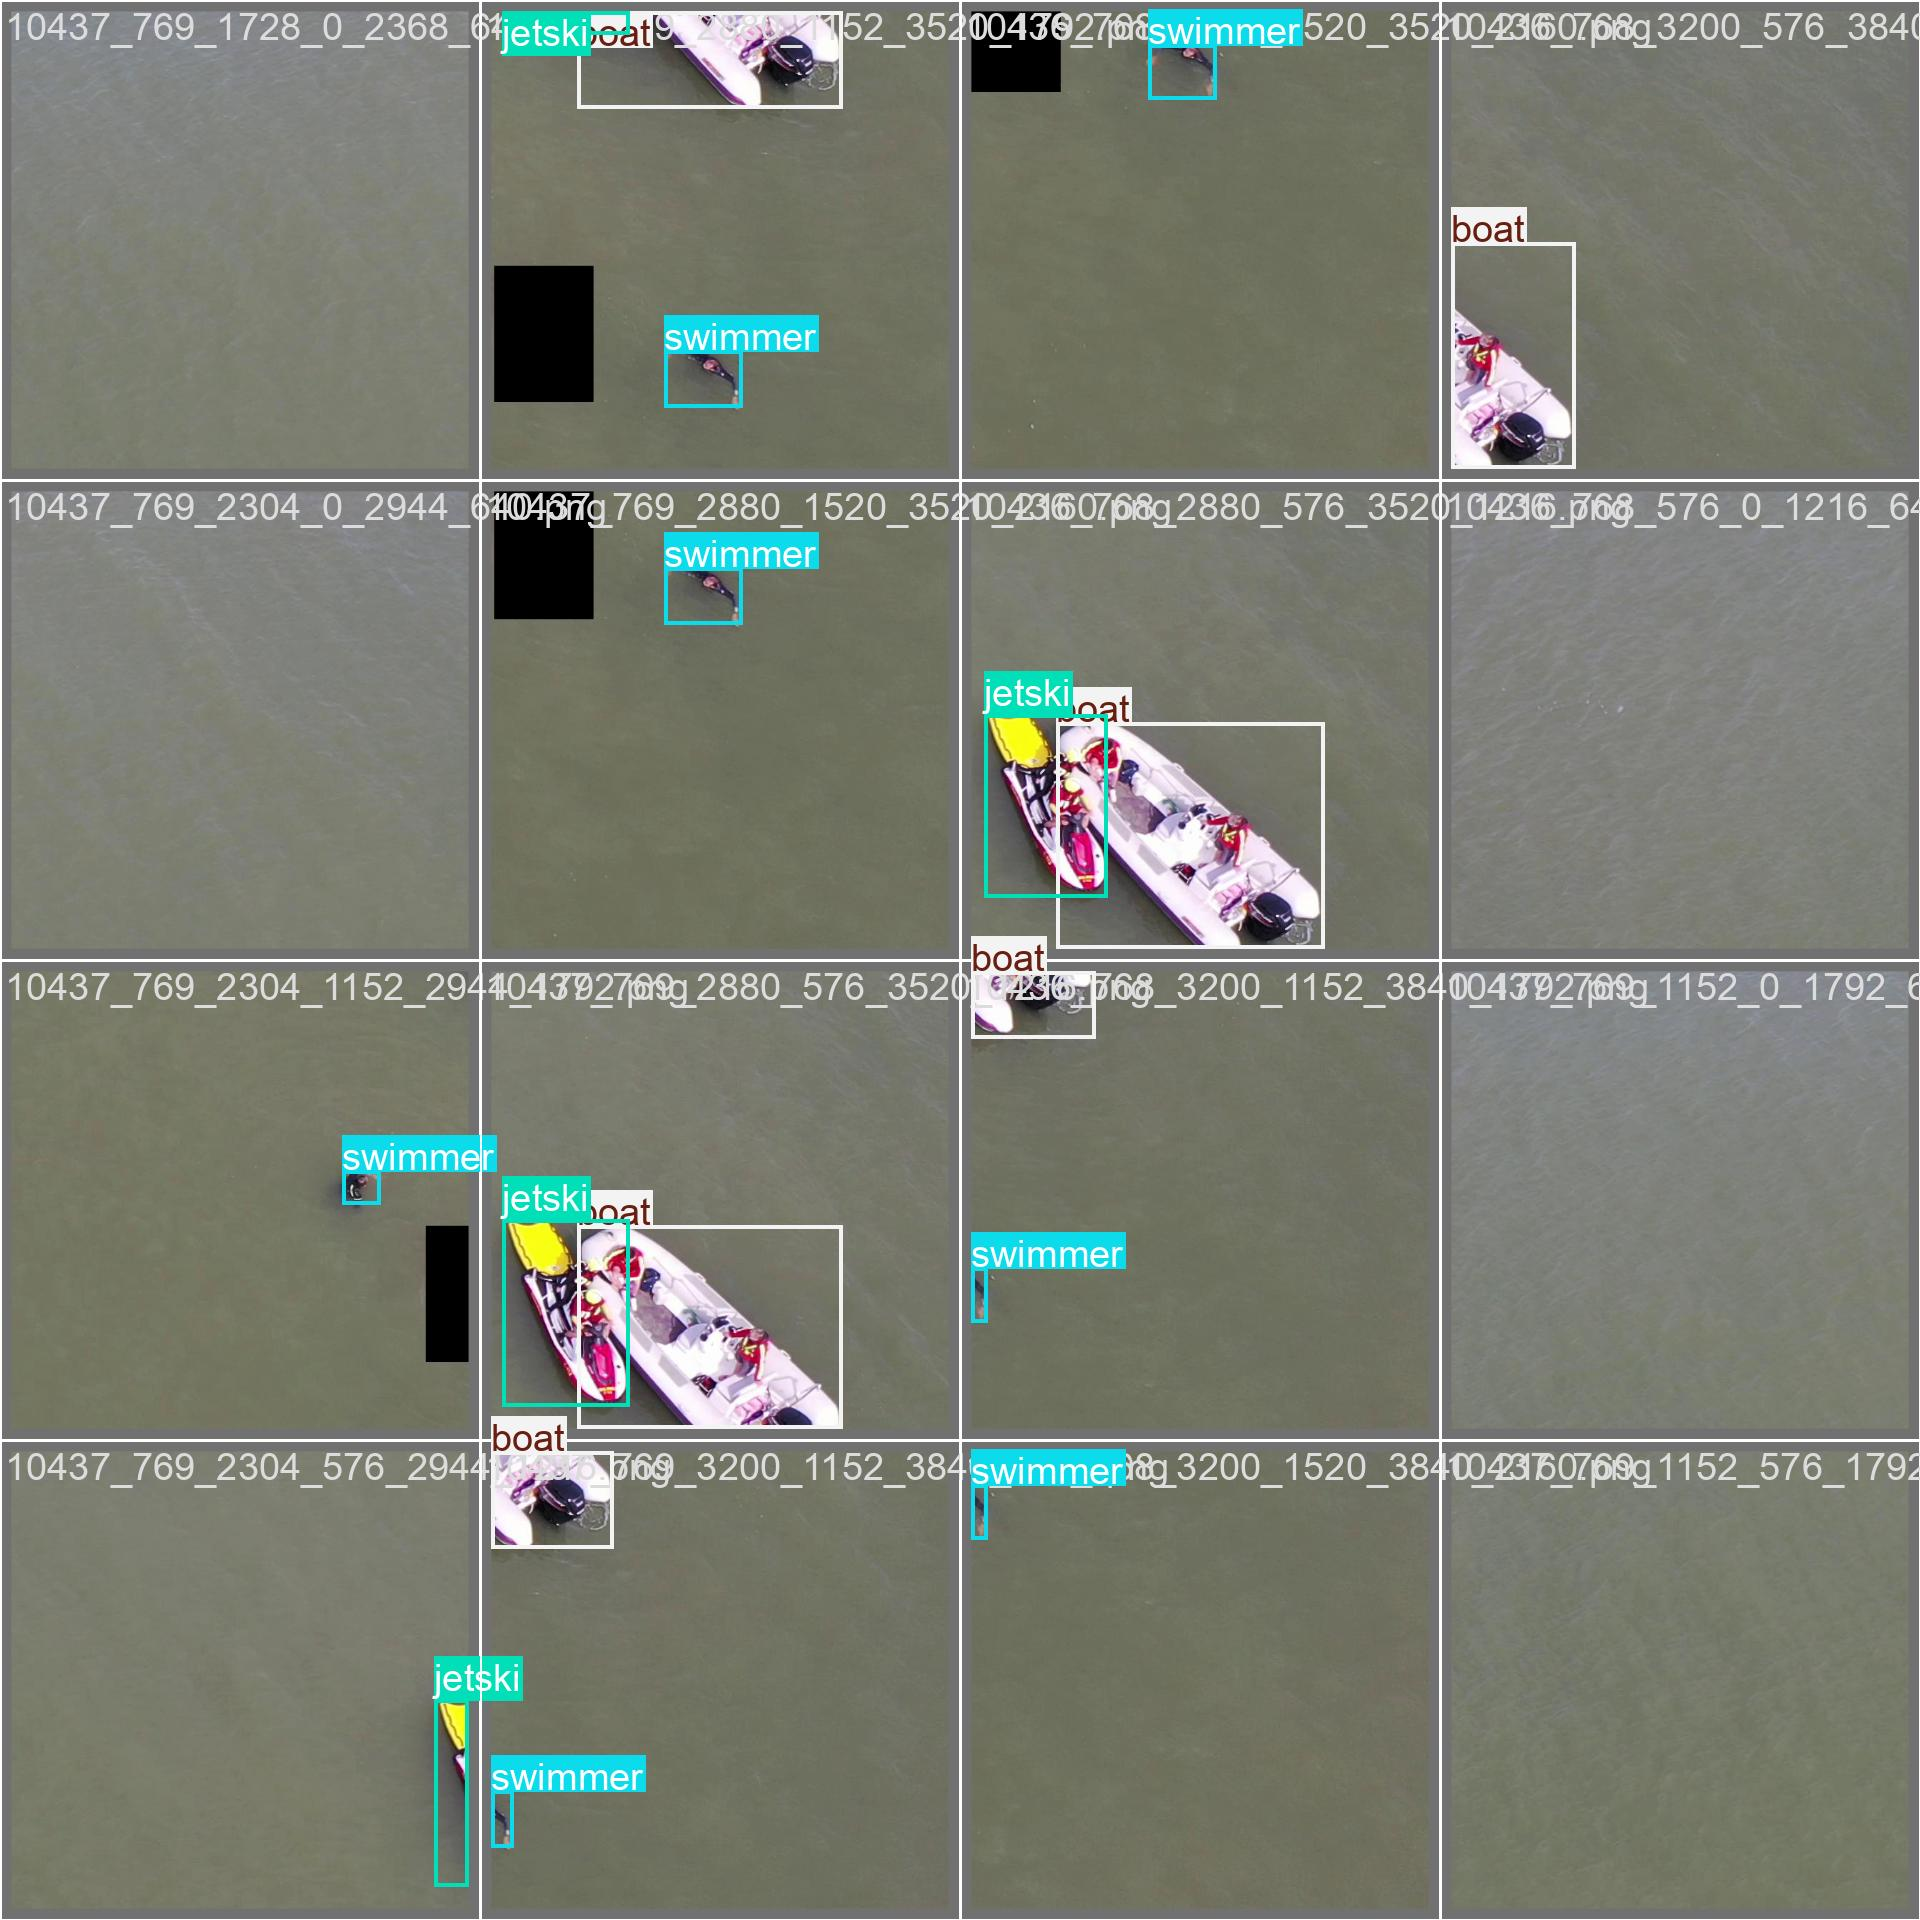

--------------------------------------------------------------------------------
Showing: val_batch1_pred.jpg


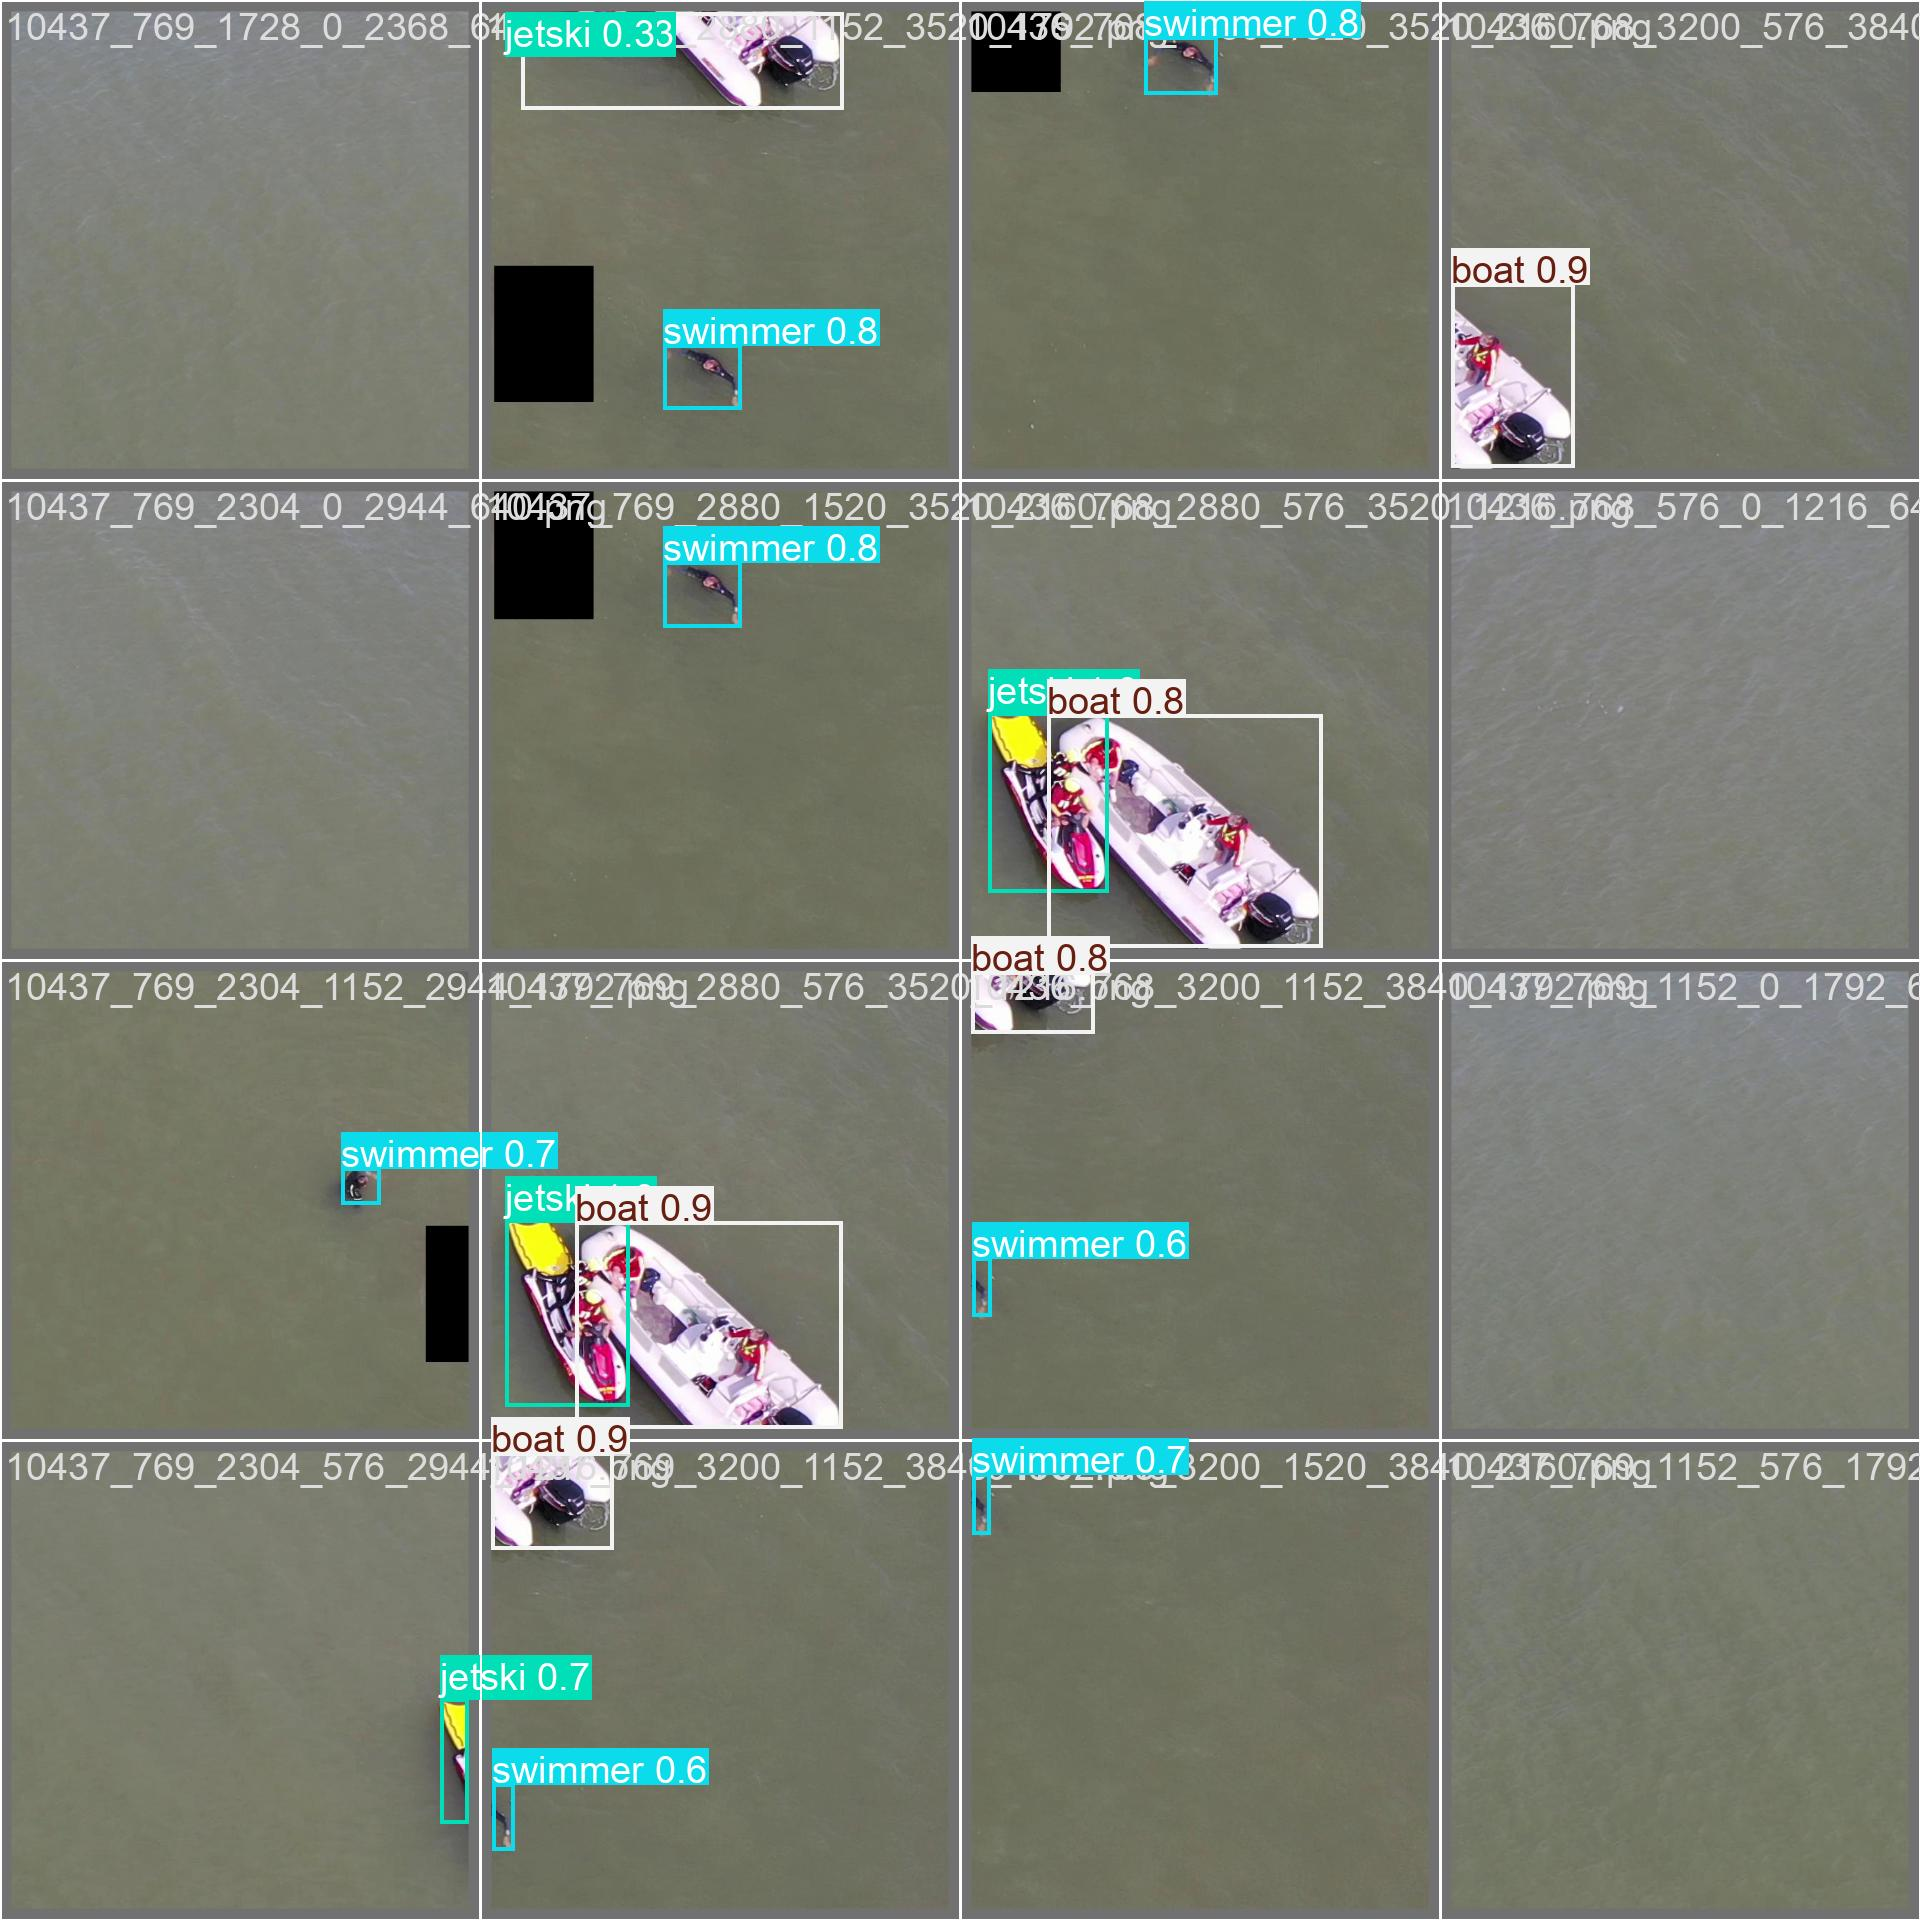

--------------------------------------------------------------------------------
Showing: val_batch2_labels.jpg


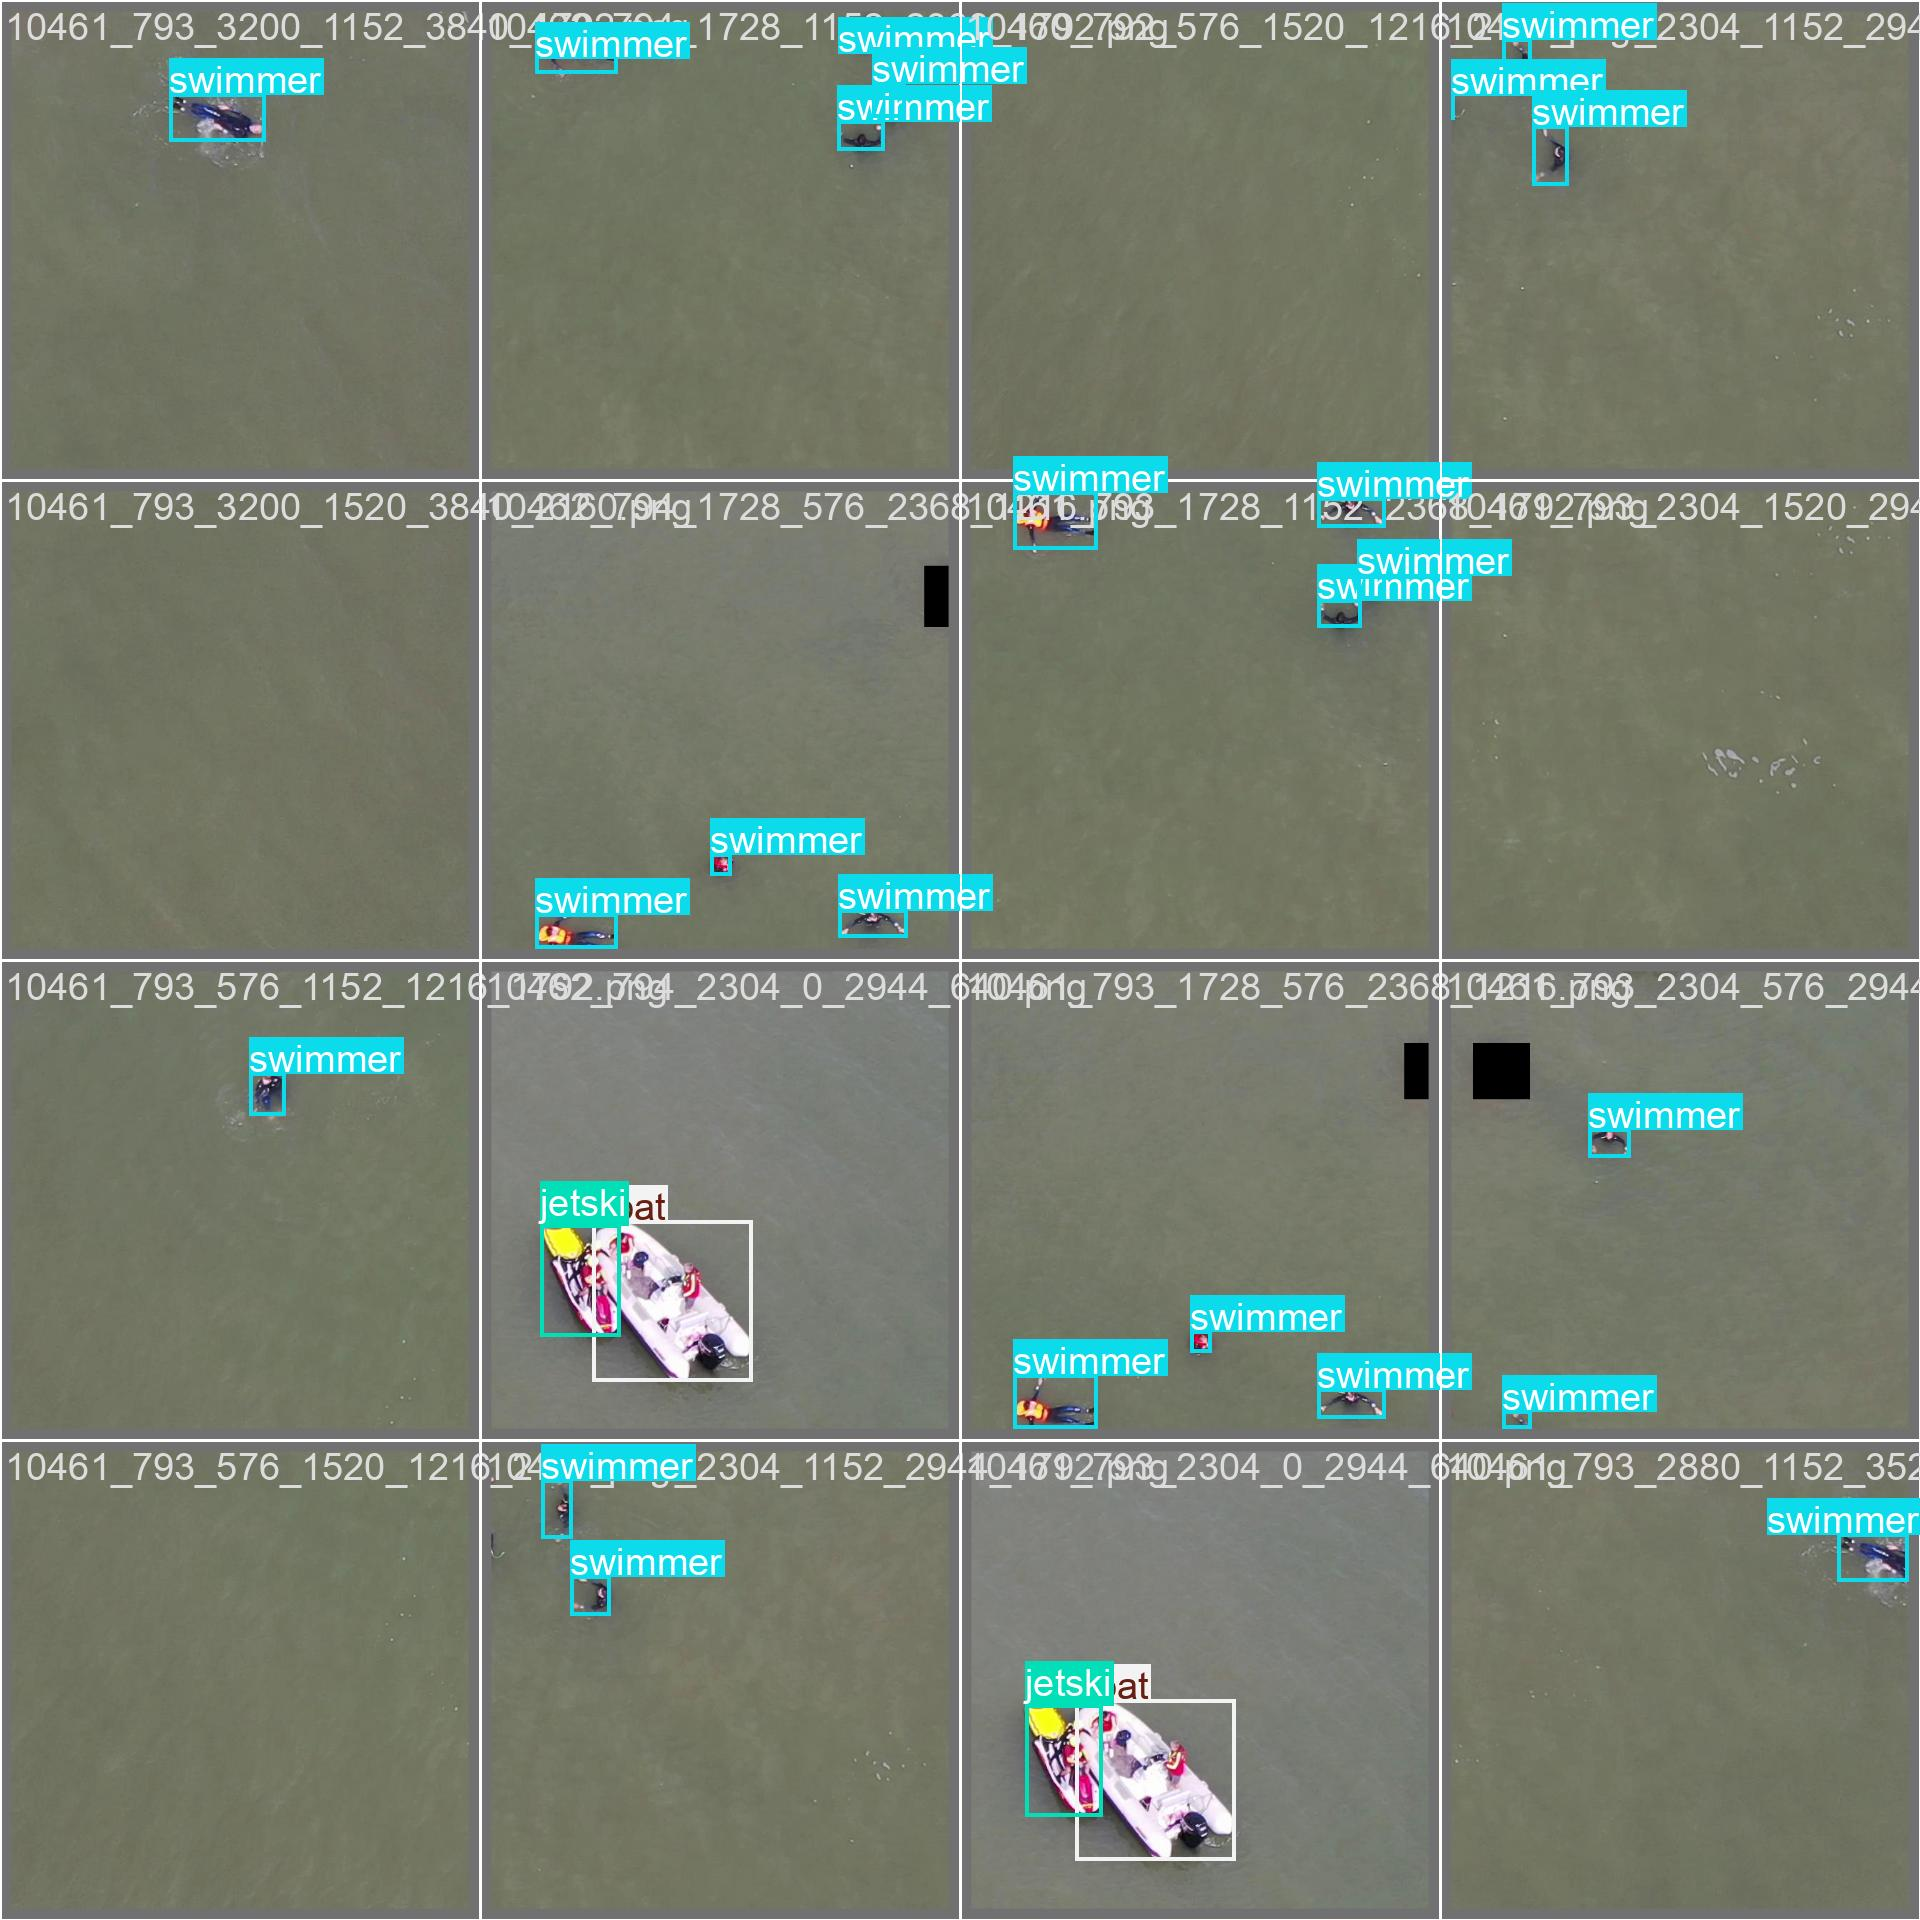

--------------------------------------------------------------------------------
Showing: val_batch2_pred.jpg


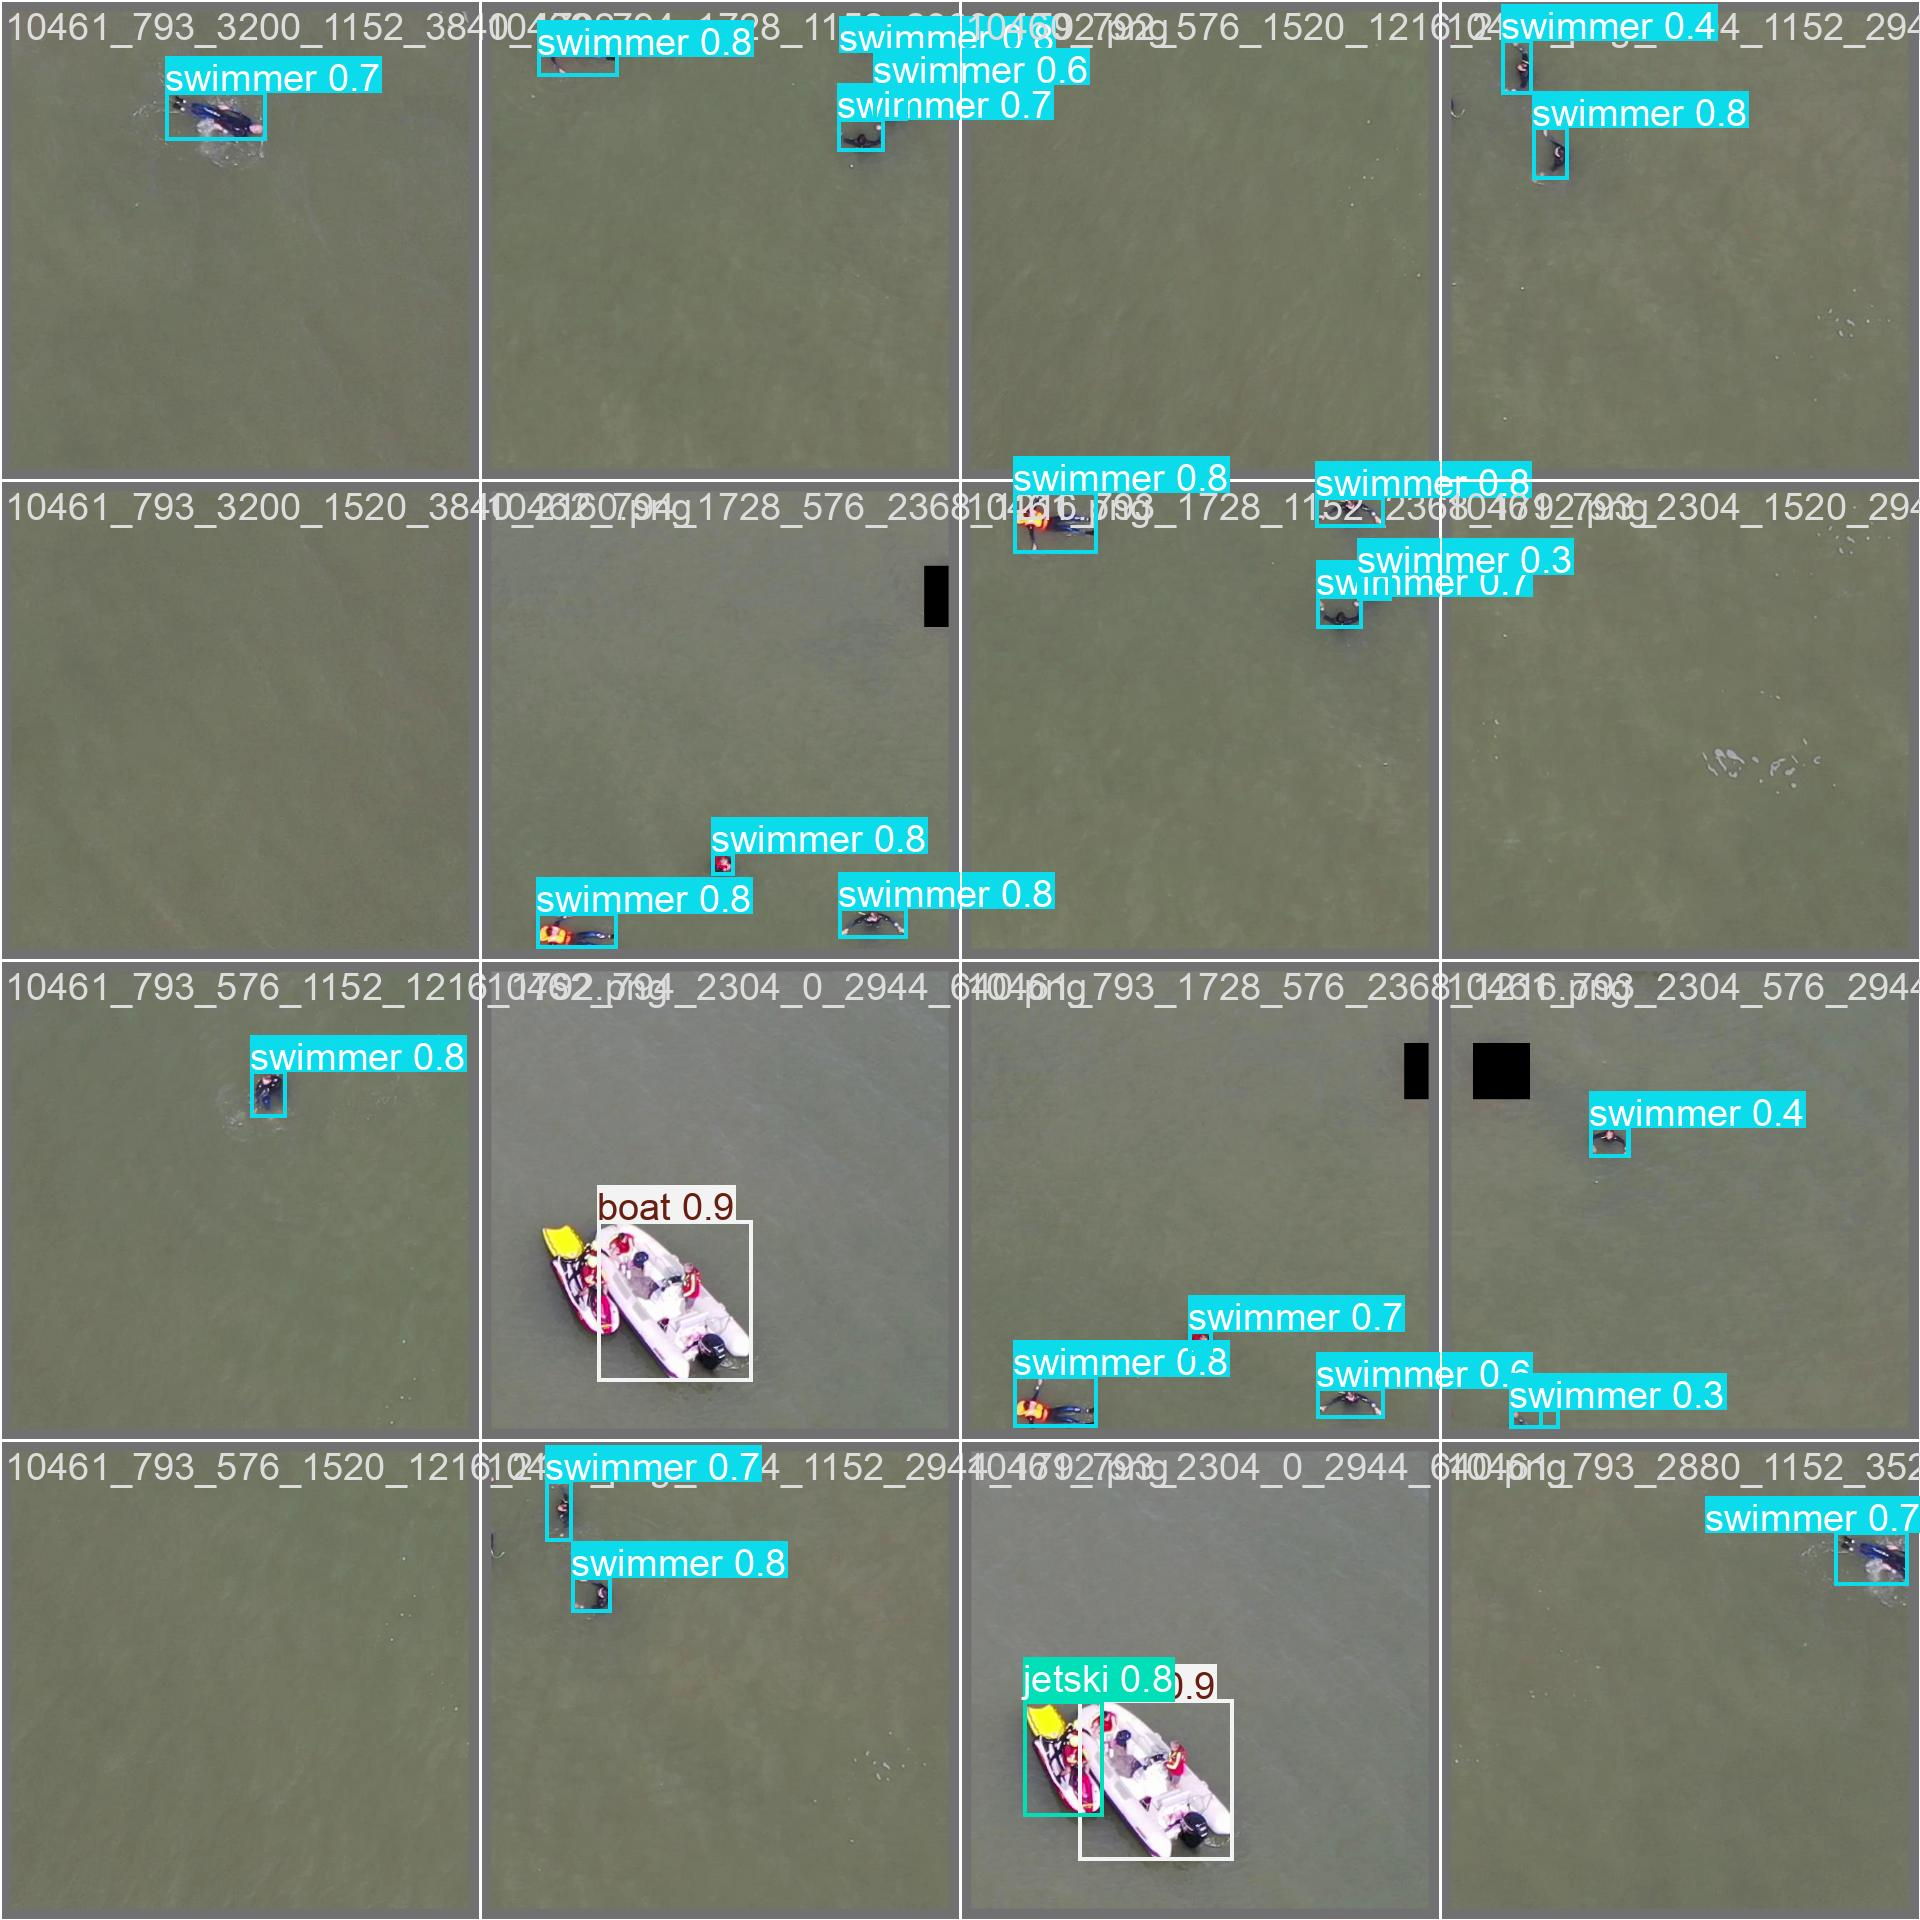

In [3]:
import os
import glob
from IPython.display import Image, display

vis_dir = '/content/project/yolov10n_sahi/'

image_files = glob.glob(os.path.join(vis_dir, '*.png')) + glob.glob(os.path.join(vis_dir, '*.jpg'))

if not image_files:
    print(f"No visualizations found in {vis_dir}.")
else:
    print(f"Found {len(image_files)} visualizations. Displaying them below:\n")
    for img_path in sorted(image_files):
        print("-" * 80)
        print(f"Showing: {os.path.basename(img_path)}")
        display(Image(filename=img_path))

## Testing the model on a single image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Please upload an image for testing.


Saving 16488.jpg to 16488.jpg
Uploaded file: 16488.jpg

image 1/1 /content/16488.jpg: 384x640 2 swimmers, 4 boats, 15.8ms
Speed: 8.7ms preprocess, 15.8ms inference, 24.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
Prediction complete. See the annotated image below:


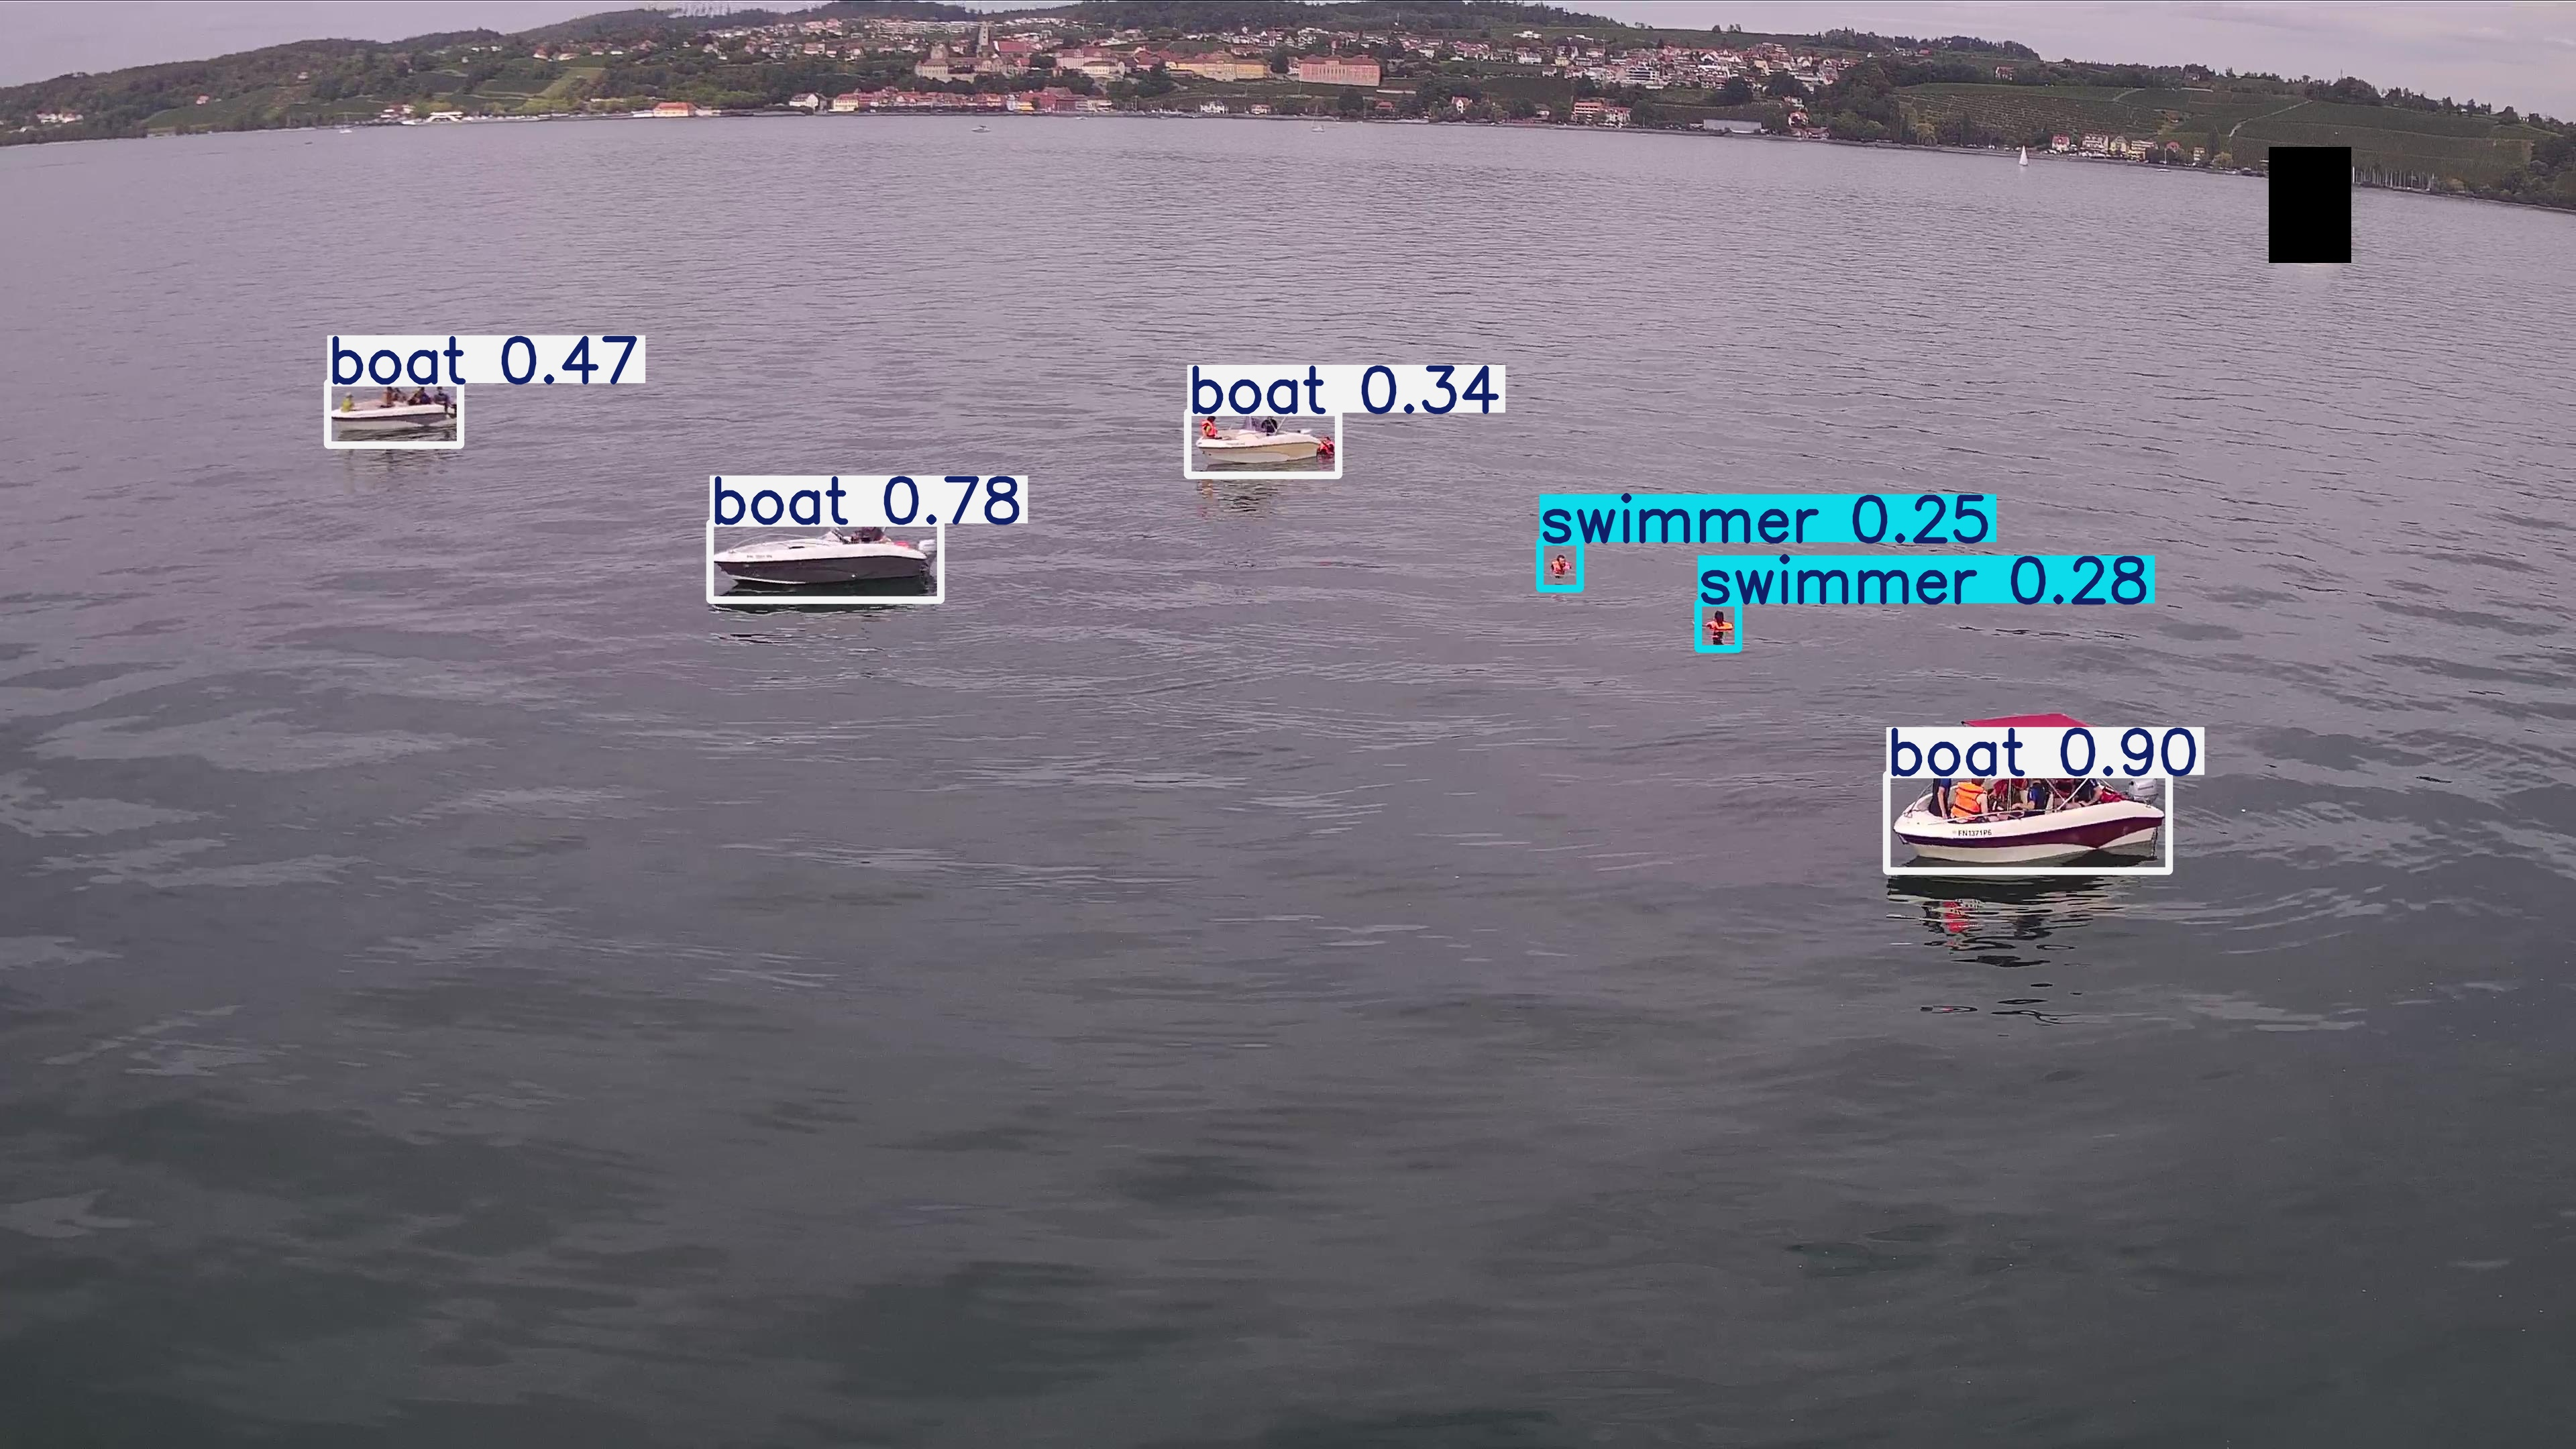


Detected objects for 16488.jpg:
  Class: boat, Confidence: 0.9, BBox: [2813, 1154, 3234, 1299]
  Class: boat, Confidence: 0.78, BBox: [1058, 779, 1402, 894]
  Class: boat, Confidence: 0.47, BBox: [489, 571, 686, 664]
  Class: boat, Confidence: 0.34, BBox: [1771, 615, 1995, 708]
  Class: swimmer, Confidence: 0.28, BBox: [2532, 899, 2592, 967]
  Class: swimmer, Confidence: 0.25, BBox: [2296, 808, 2355, 877]


In [6]:
from google.colab import files
from ultralytics import YOLO
import os
from IPython.display import Image

best_model_path = '/content/project/yolov10n_sahi/weights/best.pt'
model = YOLO(best_model_path)

print("Please upload an image for testing.")
uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f'Uploaded file: {filename}')
        test_image_path = os.path.join('/content', filename)


        results = model.predict(source=test_image_path, save=True, conf=0.25)


        print("Prediction complete. See the annotated image below:")

        if results and hasattr(results[0], 'save_dir'):

            import glob
            output_dir = results[0].save_dir
            annotated_image_files = glob.glob(os.path.join(output_dir, os.path.basename(test_image_path)))
            if annotated_image_files:
                display(Image(filename=annotated_image_files[0]))
            else:
                print(f"Annotated image not found in {output_dir}. Please check the directory manually.")

        for r in results:

            print(f"\nDetected objects for {filename}:")
            if r.boxes:
                for box in r.boxes:
                    x1, y1, x2, y2 = [round(float(val)) for val in box.xyxy[0]]
                    conf = round(float(box.conf[0]), 2)
                    cls = int(box.cls[0])
                    name = model.names[cls]
                    print(f"  Class: {name}, Confidence: {conf}, BBox: [{x1}, {y1}, {x2}, {y2}]")

else:
    print("No file uploaded.")